# Airbnb Albany — Occupancy Prediction
**Goal**: Predict the probability that a listing will be booked on a given day, based on date, room type, location, price, and review signals.

**Data**: Inside Airbnb — Albany, NY (11 months)

**Pipeline**: Load → EDA → Feature Engineering → Logistic Regression → LightGBM → Evaluation → Prediction example

## 0. Dependencies

In [ ]:
# ── Mount Google Drive (run this first) ──
from google.colab import drive
drive.mount('/content/drive')

# Place all your files in a folder called DS_group_project inside My Drive:
#   My Drive/
#     DS_group_project/
#       calendar.csv.gz
#       calendar (1).csv.gz
#       ...
#       calendar (10).csv.gz
#       listings (6).csv
#       reviews (1).csv

DATA_ROOT = '/content/drive/MyDrive/DS_group_project'  # <-- update folder name if different
print(f'Data root set to: {DATA_ROOT}')

Mounted at /content/drive
Data root set to: /content/drive/MyDrive/DS_group_project


In [ ]:
# !pip install lightgbm scikit-learn pandas matplotlib seaborn plotly

import pandas as pd
import numpy as np
import glob, os, warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay
)
import lightgbm as lgb

plt.rcParams['figure.dpi'] = 120
SEED = 42
print('Libraries loaded ✓')

Libraries loaded ✓


## 1. Load & Merge Data

**Expected directory structure**:
```
data/
  2024-09/
    calendar.csv.gz
    listings.csv
    reviews.csv
  2024-10/
    ...
```
Update `DATA_ROOT` to point to your local data folder.

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import os, time

folder = '/content/drive/MyDrive/DS_group_project'
target = 11  # you have 10 calendar files + calendar.csv.gz = 11 total

print("Waiting for files to sync...")
while True:
    files = [f for f in os.listdir(folder) if f.endswith('.gz')]
    print(f"  {len(files)}/11 .gz files ready...", end='\r')
    if len(files) >= target:
        print(f"\nAll {len(files)} files synced! Ready to run.")
        break
    time.sleep(5)

Waiting for files to sync...
  11/11 .gz files ready...
All 11 files synced! Ready to run.


In [ ]:
import glob, os

# ── Calendar: load all calendar*.csv.gz files ──
# Files are named: calendar.csv.gz, calendar (1).csv.gz, ..., calendar (10).csv.gz
cal_files = sorted(glob.glob(f'{DATA_ROOT}/calendar*.csv.gz'))
print(f'Calendar files found: {len(cal_files)}')
print('\n'.join(cal_files))  # verify paths look right

# If still 0, try escaping spaces explicitly:
if len(cal_files) == 0:
    import pathlib
    cal_files = sorted(pathlib.Path(DATA_ROOT).glob('calendar*.csv.gz'))
    cal_files = [str(f) for f in cal_files]
    print(f'Pathlib found: {len(cal_files)}')

MIN_BYTES = 1000

cal_list = []
for f in cal_files:
    size = os.path.getsize(f)
    if size < MIN_BYTES:
        print(f'  SKIPPED (too small, {size} bytes): {os.path.basename(f)}')
        continue
    tmp = pd.read_csv(f, parse_dates=['date'], low_memory=False)
    tmp['source_file'] = os.path.basename(f)
    cal_list.append(tmp)
    print(f'  Loaded {len(tmp):,} rows — {os.path.basename(f)}')

if len(cal_list) == 0:
    raise FileNotFoundError(f"No valid calendar files found in {DATA_ROOT}. Check DATA_ROOT path.")

cal = pd.concat(cal_list, ignore_index=True)
print(f'\nTotal calendar rows: {len(cal):,}  |  Date range: {cal.date.min()} ~ {cal.date.max()}')

Calendar files found: 10
/content/drive/MyDrive/DS_group_project/calendar (1).csv.gz
/content/drive/MyDrive/DS_group_project/calendar (10).csv.gz
/content/drive/MyDrive/DS_group_project/calendar (2).csv.gz
/content/drive/MyDrive/DS_group_project/calendar (3).csv.gz
/content/drive/MyDrive/DS_group_project/calendar (4).csv.gz
/content/drive/MyDrive/DS_group_project/calendar (6).csv.gz
/content/drive/MyDrive/DS_group_project/calendar (7).csv.gz
/content/drive/MyDrive/DS_group_project/calendar (8).csv.gz
/content/drive/MyDrive/DS_group_project/calendar (9).csv.gz
/content/drive/MyDrive/DS_group_project/calendar.csv.gz
  Loaded 168,265 rows — calendar (1).csv.gz
  Loaded 175,930 rows — calendar (10).csv.gz
  Loaded 169,725 rows — calendar (2).csv.gz
  Loaded 167,535 rows — calendar (3).csv.gz
  Loaded 163,155 rows — calendar (4).csv.gz
  Loaded 163,885 rows — calendar (6).csv.gz
  Loaded 158,045 rows — calendar (7).csv.gz
  Loaded 165,345 rows — calendar (8).csv.gz
  Loaded 158,410 rows — c

In [ ]:
# ── Price availability check across all sources ──

# 1. Check price in calendar files
print("=== Price in Calendar Files ===")
cal_price = cal.copy()
cal_price['price_num'] = (
    cal_price['price'].astype(str)
    .str.replace(r'[\$,]', '', regex=True)
    .pipe(pd.to_numeric, errors='coerce')
)
print(cal_price.groupby('source_file')['price_num'].agg(
    has_price=lambda x: x.notna().sum(),
    missing=lambda x: x.isna().sum(),
    missing_rate=lambda x: x.isna().mean().round(3)
).sort_values('missing_rate').to_string())

# 2. Check price in listings file
print("\n=== Price in Listings File ===")
listing_files_all = sorted(glob.glob(f'{DATA_ROOT}/listings*.csv.gz'))
for f in listing_files_all:
    tmp = pd.read_csv(f, low_memory=False, usecols=lambda c: c in ['id','price'])
    if 'price' in tmp.columns:
        valid = tmp['price'].notna().sum()
        print(f"{os.path.basename(f)}: {valid:,} / {len(tmp):,} have price ({valid/len(tmp):.1%})")
    else:
        print(f"{os.path.basename(f)}: no price column")

=== Price in Calendar Files ===
                      has_price  missing  missing_rate
source_file                                           
calendar (7).csv.gz      158045        0           0.0
calendar (6).csv.gz      163885        0           0.0
calendar (1).csv.gz           0   168265           1.0
calendar (10).csv.gz          0   175930           1.0
calendar (3).csv.gz           0   167535           1.0
calendar (2).csv.gz           0   169725           1.0
calendar (4).csv.gz           0   163155           1.0
calendar (8).csv.gz           0   165345           1.0
calendar (9).csv.gz           0   158410           1.0
calendar.csv.gz               0   174470           1.0

=== Price in Listings File ===
listings (5).csv.gz: 437 / 478 have price (91.4%)


In [ ]:
# Show first 50 rows of a file that should have no price
tmp = pd.read_csv(f'{DATA_ROOT}/calendar (3).csv.gz', nrows=500, low_memory=False)
print(tmp.to_string())

     listing_id        date available  price  adjusted_price  minimum_nights  maximum_nights
0       2992450  2025-08-04         f    NaN             NaN              28            1125
1       2992450  2025-08-05         f    NaN             NaN              28            1125
2       2992450  2025-08-06         f    NaN             NaN              28            1125
3       2992450  2025-08-07         f    NaN             NaN              28            1125
4       2992450  2025-08-08         f    NaN             NaN              28            1125
5       2992450  2025-08-09         f    NaN             NaN              28            1125
6       2992450  2025-08-10         f    NaN             NaN              28            1125
7       2992450  2025-08-11         f    NaN             NaN              28            1125
8       2992450  2025-08-12         f    NaN             NaN              28            1125
9       2992450  2025-08-13         f    NaN             NaN          

In [ ]:
# Check calendar format
print(cal.shape)
print(cal.dtypes)
cal.head(5)
cal.groupby('source_file')['date'].agg(['min','max','count'])

(1664765, 8)
listing_id                 int64
date              datetime64[ns]
available                 object
price                     object
adjusted_price           float64
minimum_nights             int64
maximum_nights             int64
source_file               object
dtype: object


,min,max,count
source_file,,,
calendar (1).csv.gz,2025-10-05,2026-10-05,168265
calendar (10).csv.gz,2025-12-11,2026-12-10,175930
calendar (2).csv.gz,2025-09-06,2026-09-05,169725
calendar (3).csv.gz,2025-08-04,2026-08-03,167535
calendar (4).csv.gz,2025-07-04,2026-07-03,163155
calendar (6).csv.gz,2025-05-02,2026-05-01,163885
calendar (7).csv.gz,2025-04-03,2026-04-02,158045
calendar (8).csv.gz,2026-02-15,2027-02-14,165345
calendar (9).csv.gz,2026-01-16,2027-01-15,158410


In [ ]:
print(cal.groupby('source_file').agg(
    min_date=('date','min'),
    max_date=('date','max'),
    listings=('listing_id','nunique'),
    rows=('listing_id','count')
).sort_values('min_date').to_string())

                       min_date   max_date  listings    rows
source_file                                                 
calendar (7).csv.gz  2025-04-03 2026-04-02       433  158045
calendar (6).csv.gz  2025-05-02 2026-05-01       449  163885
calendar (4).csv.gz  2025-07-04 2026-07-03       447  163155
calendar (3).csv.gz  2025-08-04 2026-08-03       459  167535
calendar (2).csv.gz  2025-09-06 2026-09-05       465  169725
calendar (1).csv.gz  2025-10-05 2026-10-05       461  168265
calendar.csv.gz      2025-11-07 2026-11-06       478  174470
calendar (10).csv.gz 2025-12-11 2026-12-10       482  175930
calendar (9).csv.gz  2026-01-16 2027-01-15       434  158410
calendar (8).csv.gz  2026-02-15 2027-02-14       453  165345


In [ ]:

listing_files = sorted(glob.glob(f'{DATA_ROOT}/listings*.csv.gz'))
print(f'Listings files found: {listing_files}')
# ── Listings: use the most recent listings CSV ──
listings = pd.read_csv(listing_files[-1], low_memory=False)
print(f'Listings: {len(listings):,} rows, {listings.shape[1]} columns')
# Only keep the following features
LISTING_COLS = [
    'id', 'room_type', 'neighbourhood_cleansed',
    'latitude', 'longitude',
    'accommodates', 'bedrooms', 'beds',
    'review_scores_rating', 'number_of_reviews',
    'number_of_reviews_ltm', 'reviews_per_month',
    'instant_bookable', 'minimum_nights',
    'host_is_superhost', 'host_response_rate', 'host_acceptance_rate',
]
LISTING_COLS = [c for c in LISTING_COLS if c in listings.columns]
listings = listings[LISTING_COLS].copy()
# Convert id to Listing_id for calendar.csv join
listings.rename(columns={'id': 'listing_id'}, inplace=True)
listings.head(2)

Listings files found: ['/content/drive/MyDrive/DS_group_project/listings (5).csv.gz']
Listings: 478 rows, 79 columns


,listing_id,room_type,neighbourhood_cleansed,latitude,longitude,accommodates,bedrooms,beds,review_scores_rating,number_of_reviews,number_of_reviews_ltm,reviews_per_month,instant_bookable,minimum_nights,host_is_superhost,host_response_rate,host_acceptance_rate
0,2992450,Entire home/apt,THIRD WARD,42.65789,-73.75370,4,2.0,2.0,3.56,9,0,0.07,f,28,f,NaN,50%
1,3820211,Entire home/apt,SIXTH WARD,42.65222,-73.76724,3,1.0,1.0,4.75,314,8,2.30,f,2,t,100%,99%


In [ ]:
# ── Reviews: use the most recent one too ──
rev_files = sorted(glob.glob(f'{DATA_ROOT}/reviews*.csv'))
print(f'Reviews files found: {rev_files}')
reviews = pd.concat(
    [pd.read_csv(f, parse_dates=['date']) for f in rev_files],
    ignore_index=True
).drop_duplicates()

last_review = (
    reviews.groupby('listing_id')['date']
    .max().reset_index()
    .rename(columns={'date': 'last_review_date'})
)
listings = listings.drop(columns=['last_review_date'], errors='ignore')
listings = listings.merge(last_review, on='listing_id', how='left')

# ── Build main dataset ──
cal['price_num'] = (
    cal['price'].astype(str)
    .str.replace(r'[\\$,]', '', regex=True)
    .pipe(pd.to_numeric, errors='coerce')
)
cal['booked'] = (cal['available'] == 'f').astype(int)

# Sort by true snapshot order (min date per file) before deduplication
snapshot_dates = cal.groupby('source_file')['date'].min().rename('snapshot_date')
cal = cal.join(snapshot_dates, on='source_file')
cal_dedup = (
    cal.sort_values('snapshot_date')
    .drop_duplicates(subset=['listing_id','date'], keep='last')
)

df = cal_dedup.merge(listings, on='listing_id', how='left')
print(f'Main dataset: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Overall occupancy rate: {df.booked.mean():.1%}')

Reviews files found: ['/content/drive/MyDrive/DS_group_project/reviews (1).csv']
Main dataset: 365,082 rows x 28 columns
Overall occupancy rate: 38.6%


In [ ]:
print("=== Price Missing Rate ===")
total = len(df)
missing = df['price_num'].isna().sum()
valid = df['price_num'].notna().sum()

print(f"Total rows:   {total:,}")
print(f"Has price:    {valid:,}  ({valid/total:.1%})")
print(f"Missing:      {missing:,}  ({missing/total:.1%})")

print("\n=== By Room Type ===")
print(
    df.groupby('room_type')['price_num']
    .apply(lambda x: x.isna().mean())
    .round(3)
    .rename('missing_rate')
)

print("\n=== By Snapshot Date ===")
print(
    df.groupby('snapshot_date')['price_num']
    .apply(lambda x: x.isna().mean())
    .round(3)
    .rename('missing_rate')
)

=== Price Missing Rate ===
Total rows:   365,082
Has price:    52,508  (14.4%)
Missing:      312,574  (85.6%)

=== By Room Type ===
room_type
Entire home/apt    0.890
Hotel room         1.000
Private room       0.876
Name: missing_rate, dtype: float64

=== By Snapshot Date ===
snapshot_date
2025-04-03    0.0
2025-05-02    0.0
2025-07-04    1.0
2025-08-04    1.0
2025-09-06    1.0
2025-10-05    1.0
2025-11-07    1.0
2025-12-11    1.0
2026-01-16    1.0
2026-02-15    1.0
Name: missing_rate, dtype: float64


## 2. EDA — Exploratory Data Analysis

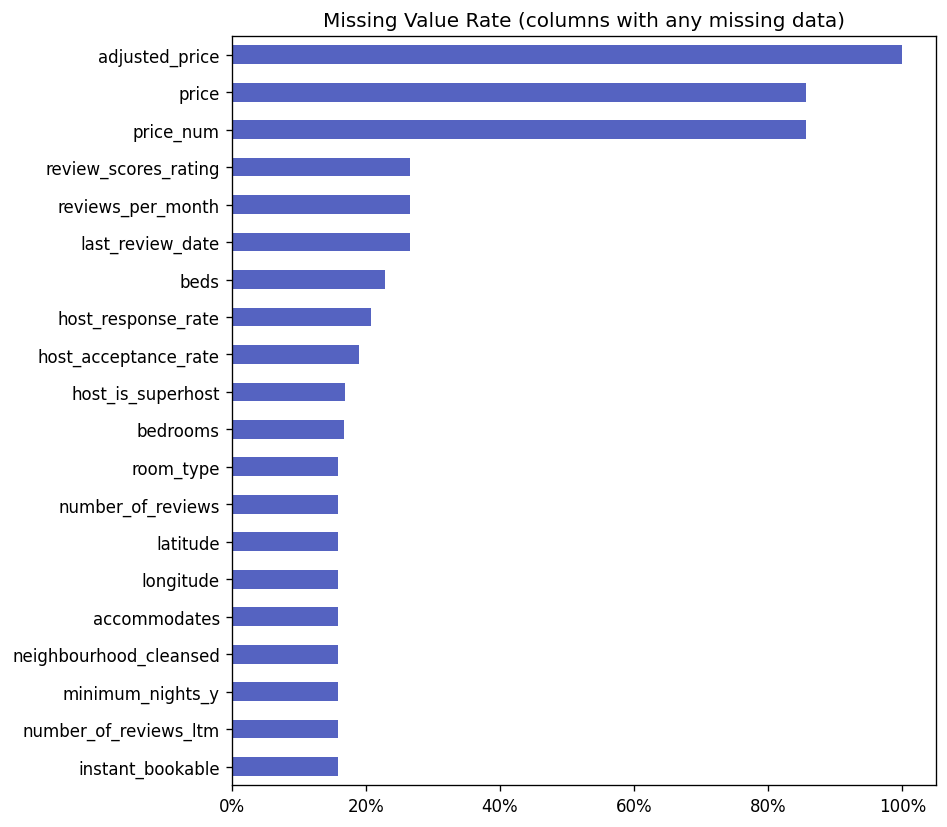

In [ ]:
# 2.1 Missing values
miss = df.isnull().mean().sort_values(ascending=False)
miss = miss[miss > 0]
fig, ax = plt.subplots(figsize=(8, max(3, len(miss) * 0.35)))
miss.plot.barh(ax=ax, color='#5563c1')
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1))
ax.set_title('Missing Value Rate (columns with any missing data)')
ax.invert_yaxis()
plt.tight_layout(); plt.show()

=== Cost-Benefit Assumptions (from report) ===
Median nightly price           : $104.00
Airbnb service fee rate        : 15.5%
TP fee per night               : +$16.12  (full service fee)
FN fee per night               : +$12.90  (20% discounted booking)
FP cost per night              : -$52.00  (50% median — vacancy risk)
TN cost per night              :  $0.00  (correctly predicted vacant)

=== Confusion Matrix (threshold=0.64) ===
True Positive  (TP): 4,083  → +$65,817.96
False Positive (FP): 926  → -$48,152.00
False Negative (FN): 1,347  → +$17,370.91
True Negative  (TN): 11,102  →  $0.00

Total estimated revenue : $35,036.87
Theoretical max revenue : $87,531.60
Revenue captured        : 40.0%

=== Revenue-Optimal Threshold ===
Threshold that maximizes revenue : 0.85  (revenue = $72,909.30)
Revenue at F1-optimal  (0.64)    : $36,669.46
Revenue at default     (0.50)    : $-21,089.54


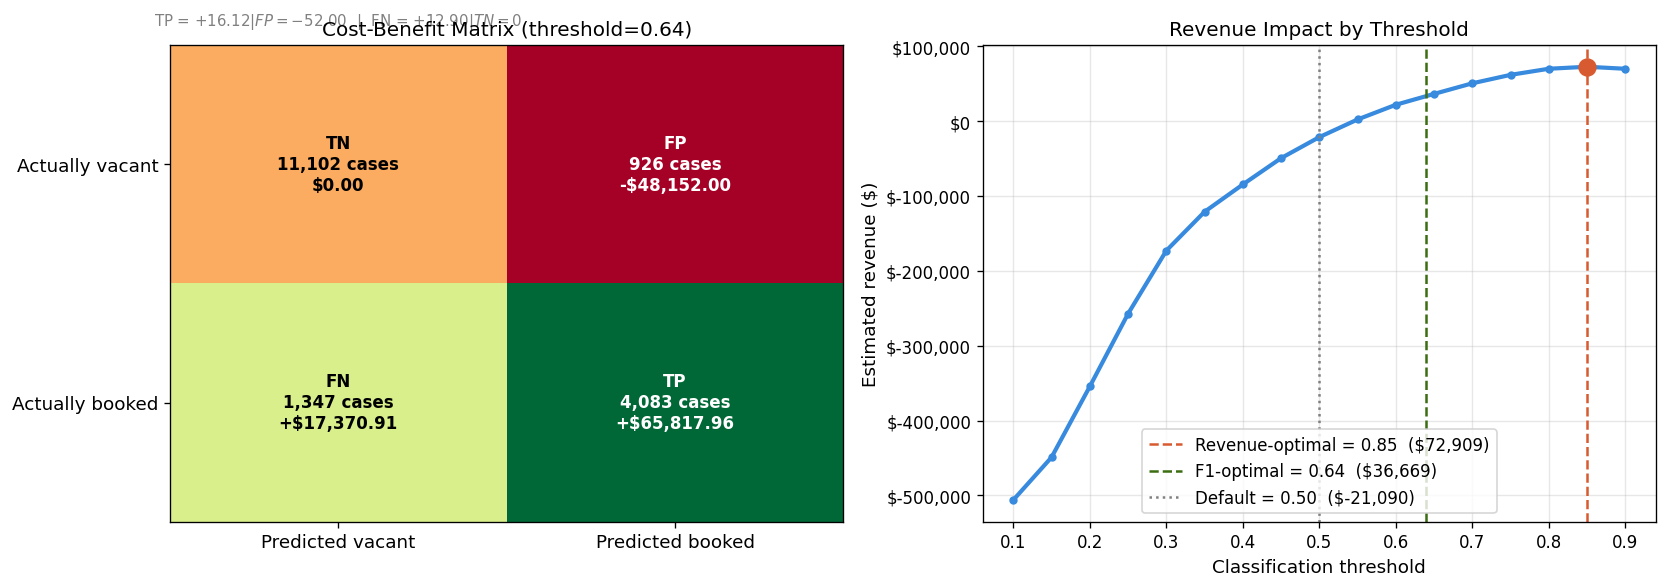

In [ ]:
# ============================================================
# Cost-Benefit Analysis — aligned with report assumptions
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# --- Step 1: Fixed assumptions from report ---
median_price     = 104.00
airbnb_fee_rate  = 0.155
price_reduction  = 0.20

tp_fee  = median_price * airbnb_fee_rate                        # +$16.12
fn_fee  = median_price * (1 - price_reduction) * airbnb_fee_rate  # +$12.90
fp_cost = median_price * 0.50                                   # -$52.00
tn_cost = 0                                                     # $0

print("=== Cost-Benefit Assumptions (from report) ===")
print(f"Median nightly price           : ${median_price:.2f}")
print(f"Airbnb service fee rate        : {airbnb_fee_rate:.1%}")
print(f"TP fee per night               : +${tp_fee:.2f}  (full service fee)")
print(f"FN fee per night               : +${fn_fee:.2f}  (20% discounted booking)")
print(f"FP cost per night              : -${fp_cost:.2f}  (50% median — vacancy risk)")
print(f"TN cost per night              :  ${tn_cost:.2f}  (correctly predicted vacant)")

# --- Step 2: Confusion matrix at F1-optimal threshold ---
best_threshold = 0.64
y_pred_cost    = (ensemble_prob >= best_threshold).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_cost).ravel()

revenue_tp = tp * tp_fee
revenue_fn = fn * fn_fee
revenue_fp = fp * fp_cost
total_revenue = revenue_tp + revenue_fn - revenue_fp
max_revenue   = (tp + fn) * tp_fee

print(f"\n=== Confusion Matrix (threshold={best_threshold}) ===")
print(f"True Positive  (TP): {tp:,}  → +${revenue_tp:,.2f}")
print(f"False Positive (FP): {fp:,}  → -${revenue_fp:,.2f}")
print(f"False Negative (FN): {fn:,}  → +${revenue_fn:,.2f}")
print(f"True Negative  (TN): {tn:,}  →  $0.00")
print(f"\nTotal estimated revenue : ${total_revenue:,.2f}")
print(f"Theoretical max revenue : ${max_revenue:,.2f}")
print(f"Revenue captured        : {total_revenue/max_revenue:.1%}")

# --- Step 3: Revenue curve across thresholds ---
thresholds_range = np.arange(0.10, 0.95, 0.05)
revenues = []

for t in thresholds_range:
    y_pred_t = (ensemble_prob >= t).astype(int)
    tn_t, fp_t, fn_t, tp_t = confusion_matrix(y_test, y_pred_t).ravel()
    rev = tp_t * tp_fee + fn_t * fn_fee - fp_t * fp_cost
    revenues.append(rev)

revenues = np.array(revenues)
best_rev_idx       = np.argmax(revenues)
best_rev_threshold = thresholds_range[best_rev_idx]
best_revenue       = revenues[best_rev_idx]

print(f"\n=== Revenue-Optimal Threshold ===")
print(f"Threshold that maximizes revenue : {best_rev_threshold:.2f}  (revenue = ${best_revenue:,.2f})")
print(f"Revenue at F1-optimal  (0.64)    : ${revenues[np.argmin(np.abs(thresholds_range - 0.64))]:,.2f}")
print(f"Revenue at default     (0.50)    : ${revenues[np.argmin(np.abs(thresholds_range - 0.50))]:,.2f}")

# --- Step 4: Plot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cost-benefit matrix
cm_labels = np.array([
    [f"TN\n{tn:,} cases\n$0.00",
     f"FP\n{fp:,} cases\n-${revenue_fp:,.2f}"],
    [f"FN\n{fn:,} cases\n+${revenue_fn:,.2f}",
     f"TP\n{tp:,} cases\n+${revenue_tp:,.2f}"]
])
cm_colors = np.array([
    [0.3, 0.0],
    [0.6, 1.0]
])

axes[0].imshow(cm_colors, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
axes[0].set_xticks([0, 1])
axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(['Predicted vacant', 'Predicted booked'], fontsize=11)
axes[0].set_yticklabels(['Actually vacant', 'Actually booked'], fontsize=11)
axes[0].set_title(f'Cost-Benefit Matrix (threshold={best_threshold})', fontsize=12)

for i in range(2):
    for j in range(2):
        axes[0].text(j, i, cm_labels[i, j], ha='center', va='center',
                    fontsize=10, fontweight='bold',
                    color='white' if cm_colors[i,j] > 0.7 or cm_colors[i,j] < 0.2 else 'black')

# Annotate cost assumptions
axes[0].text(0, -0.6, f"TP = +${tp_fee:.2f}  |  FP = -${fp_cost:.2f}  |  FN = +${fn_fee:.2f}  |  TN = $0",
            ha='center', va='center', fontsize=9,
            color='gray', transform=axes[0].transData)

# Revenue curve
axes[1].plot(thresholds_range, revenues, color='#378ADD', lw=2.5, marker='o', markersize=4)
axes[1].axvline(best_rev_threshold, color='#D85A30', linestyle='--', lw=1.5,
                label=f'Revenue-optimal = {best_rev_threshold:.2f}  (${best_revenue:,.0f})')
axes[1].axvline(0.64, color='#3B6D11', linestyle='--', lw=1.5,
                label=f'F1-optimal = 0.64  (${revenues[np.argmin(np.abs(thresholds_range - 0.64))]:,.0f})')
axes[1].axvline(0.50, color='gray',    linestyle=':',  lw=1.5,
                label=f'Default = 0.50  (${revenues[np.argmin(np.abs(thresholds_range - 0.50))]:,.0f})')
axes[1].scatter([best_rev_threshold], [best_revenue], color='#D85A30', zorder=5, s=100)
axes[1].set_xlabel('Classification threshold', fontsize=11)
axes[1].set_ylabel('Estimated revenue ($)', fontsize=11)
axes[1].set_title('Revenue Impact by Threshold', fontsize=12)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

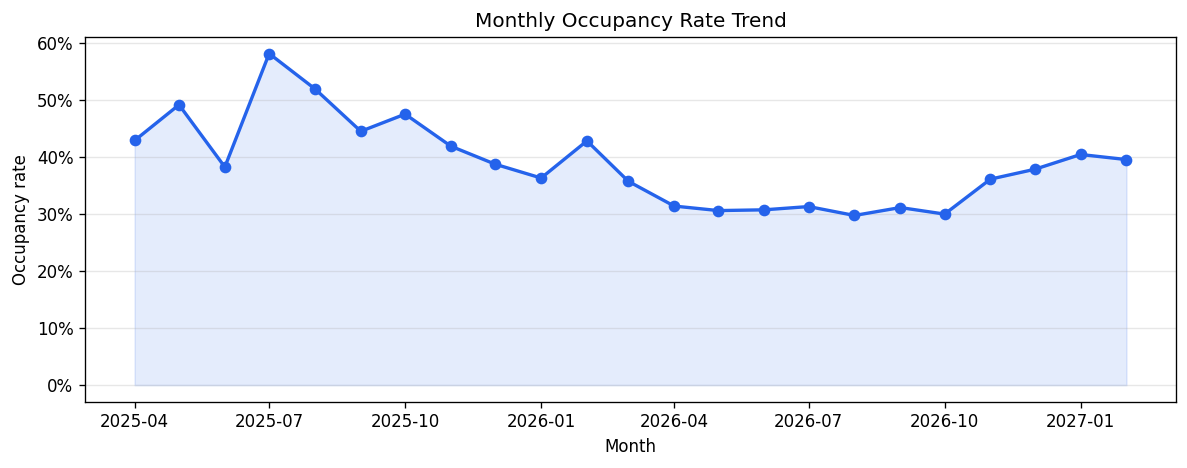

In [ ]:
# 2.2 Monthly occupancy trend
monthly = df.groupby(df['date'].dt.to_period('M'))['booked'].mean().reset_index()
monthly['date'] = monthly['date'].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(monthly['date'], monthly['booked'], marker='o', color='#2563eb', linewidth=2)
ax.fill_between(monthly['date'], monthly['booked'], alpha=0.12, color='#2563eb')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1))
ax.set_title('Monthly Occupancy Rate Trend')
ax.set_xlabel('Month'); ax.set_ylabel('Occupancy rate')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

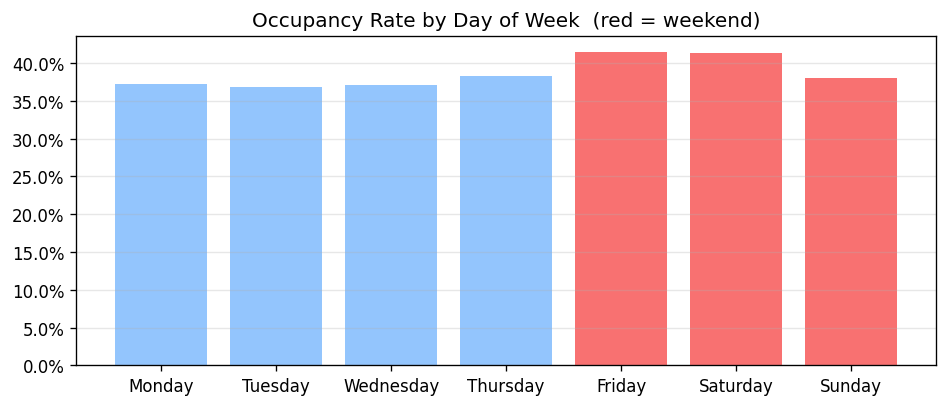

In [ ]:
# 2.3 Occupancy by day of week
df['day_of_week'] = df['date'].dt.day_name()
DOW_ORDER = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow = df.groupby('day_of_week')['booked'].mean().reindex(DOW_ORDER).reset_index()

fig, ax = plt.subplots(figsize=(8, 3.5))
colors = ['#f87171' if d in ['Friday','Saturday','Sunday'] else '#93c5fd' for d in dow['day_of_week']]
ax.bar(dow['day_of_week'], dow['booked'], color=colors)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1))
ax.set_title('Occupancy Rate by Day of Week  (red = weekend)')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

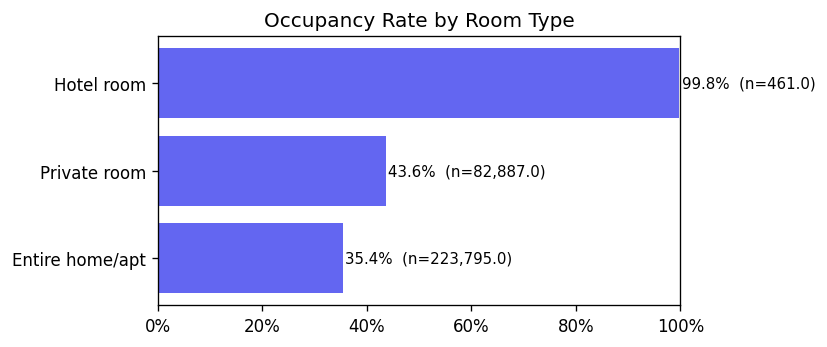

In [ ]:
# 2.4 Occupancy by room type
if 'room_type' in df.columns:
    rt = df.groupby('room_type')['booked'].agg(['mean','count']).sort_values('mean', ascending=False)
    fig, ax = plt.subplots(figsize=(7, 3))
    ax.barh(rt.index, rt['mean'], color='#6366f1')
    for i, (idx, row) in enumerate(rt.iterrows()):
        ax.text(row['mean'] + 0.005, i, f"{row['mean']:.1%}  (n={row['count']:,})", va='center', fontsize=9)
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(1))
    ax.set_title('Occupancy Rate by Room Type')
    ax.set_xlim(0, 1.0); ax.invert_yaxis()
    plt.tight_layout(); plt.show()

['listing_id', 'date', 'available', 'price', 'adjusted_price', 'minimum_nights_x', 'maximum_nights', 'source_file', 'price_num', 'booked', 'snapshot_date', 'room_type', 'neighbourhood_cleansed', 'latitude', 'longitude', 'accommodates', 'bedrooms', 'beds', 'review_scores_rating', 'number_of_reviews', 'number_of_reviews_ltm', 'reviews_per_month', 'instant_bookable', 'minimum_nights_y', 'host_is_superhost', 'host_response_rate', 'host_acceptance_rate', 'last_review_date', 'has_review_score', 'has_host_response', 'day_of_week']
['listing_id', 'room_type', 'neighbourhood_cleansed', 'latitude', 'longitude', 'accommodates', 'bedrooms', 'beds', 'review_scores_rating', 'number_of_reviews', 'number_of_reviews_ltm', 'reviews_per_month', 'instant_bookable', 'minimum_nights', 'host_is_superhost', 'host_response_rate', 'host_acceptance_rate', 'last_review_date']


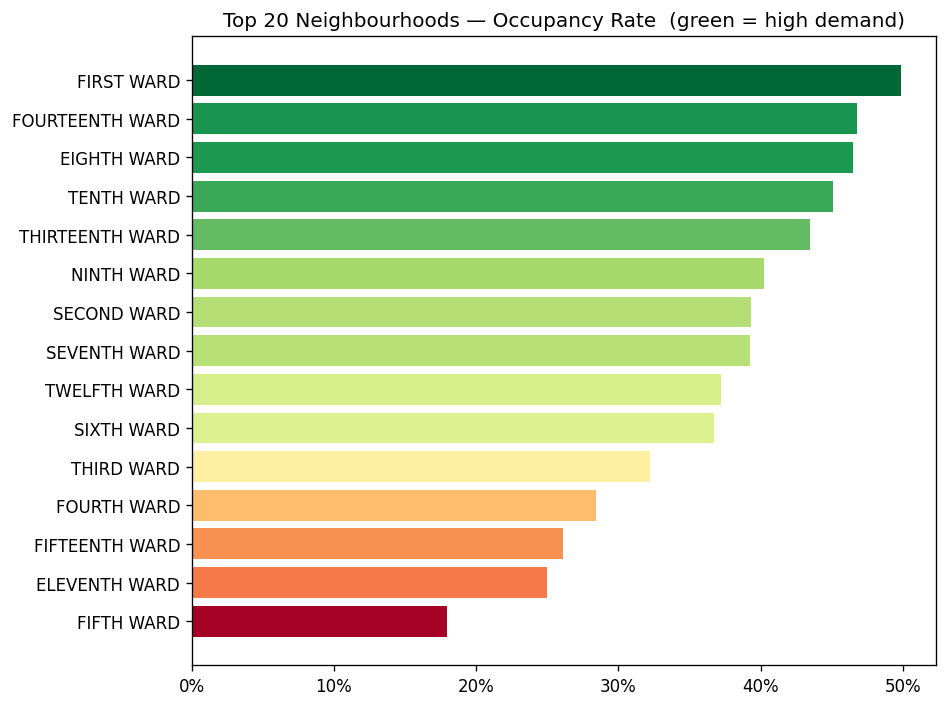

In [ ]:
# 2.5 Top 20 neighbourhoods by occupancy rate
print(df.columns.tolist())
print(listings.columns.tolist())
if 'neighbourhood_cleansed' in df.columns:
    nbhd = (
        df.groupby('neighbourhood_cleansed')['booked']
        .agg(['mean','count'])
        .query('count >= 100')
        .sort_values('mean', ascending=False)
        .head(20)
    )
    fig, ax = plt.subplots(figsize=(8, max(4, len(nbhd) * 0.4)))
    vals = nbhd['mean']
    norm = (vals - vals.min()) / (vals.max() - vals.min() + 1e-9)
    colors = [plt.cm.RdYlGn(v) for v in norm]
    ax.barh(nbhd.index, nbhd['mean'], color=colors)
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(1))
    ax.set_title('Top 20 Neighbourhoods — Occupancy Rate  (green = high demand)')
    ax.invert_yaxis()
    plt.tight_layout(); plt.show()

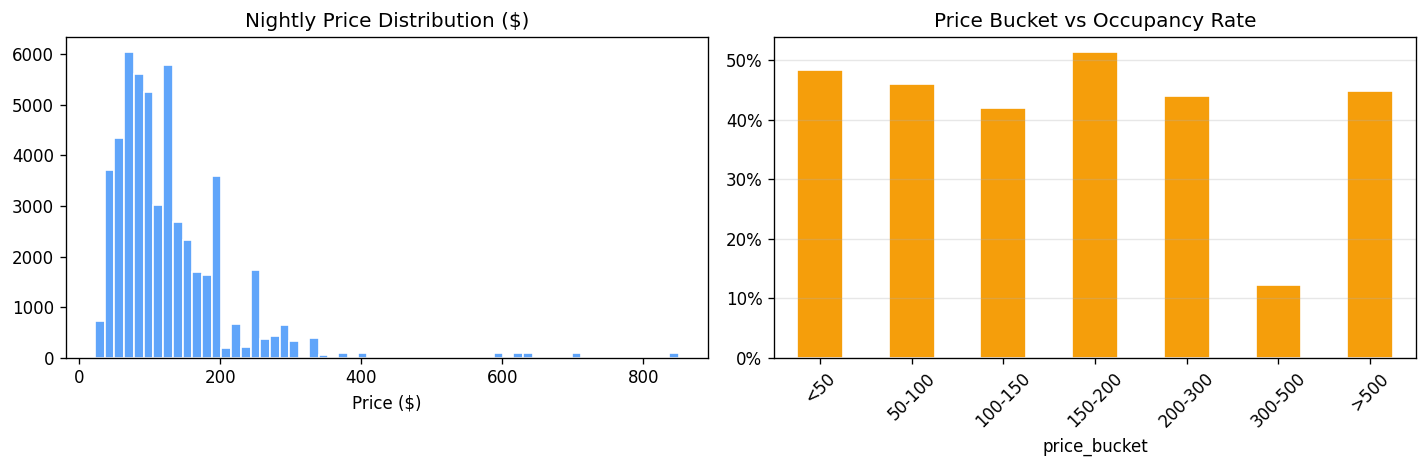

In [ ]:
# 2.6 Price distribution & price bucket vs occupancy
df_v = df[df['price_num'].between(10, 1000)].copy()
df_v['price_bucket'] = pd.cut(
    df_v['price_num'],
    bins=[0, 50, 100, 150, 200, 300, 500, 1000],
    labels=['<50','50-100','100-150','150-200','200-300','300-500','>500']
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df_v['price_num'], bins=60, color='#60a5fa', edgecolor='white')
axes[0].set_title('Nightly Price Distribution ($)')
axes[0].set_xlabel('Price ($)')

df_v.groupby('price_bucket')['booked'].mean().plot.bar(
    ax=axes[1], color='#f59e0b', edgecolor='white', rot=45)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1))
axes[1].set_title('Price Bucket vs Occupancy Rate')
axes[1].grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

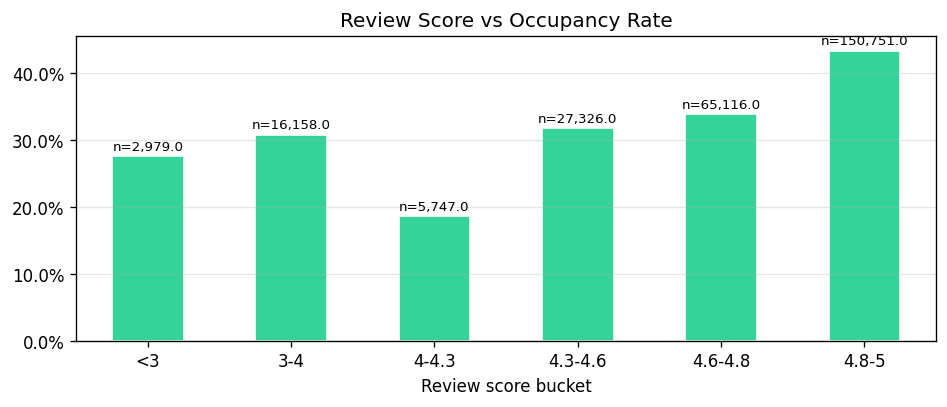

In [ ]:
# 2.7 Review score vs occupancy
if 'review_scores_rating' in df.columns:
    df['review_bucket'] = pd.cut(
        df['review_scores_rating'],
        bins=[0, 3, 4, 4.3, 4.6, 4.8, 5.01],
        labels=['<3','3-4','4-4.3','4.3-4.6','4.6-4.8','4.8-5']
    )
    rev_occ = df.groupby('review_bucket')['booked'].agg(['mean','count'])
    fig, ax = plt.subplots(figsize=(8, 3.5))
    rev_occ['mean'].plot.bar(ax=ax, color='#34d399', edgecolor='white', rot=0)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1))
    ax.set_title('Review Score vs Occupancy Rate')
    ax.set_xlabel('Review score bucket')
    for i, (idx, row) in enumerate(rev_occ.iterrows()):
        ax.text(i, row['mean'] + 0.005, f"n={row['count']:,}", ha='center', va='bottom', fontsize=8)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout(); plt.show()

Using 12 features for MI analysis


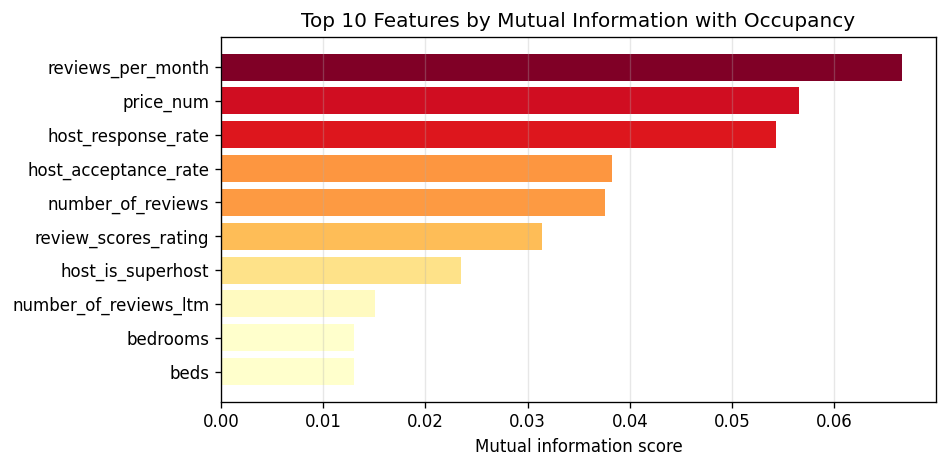

In [ ]:
# 2.8 Top 10 features most associated with occupancy (using Mutual Information)
from sklearn.feature_selection import mutual_info_classif
from sklearn.impute import SimpleImputer

# Only use columns that already exist in df at this point
mi_features = [
    'price_num', 'month', 'day_of_week_n', 'is_weekend', 'quarter',
    'accommodates', 'bedrooms', 'beds', 'minimum_nights',
    'review_scores_rating', 'number_of_reviews',
    'number_of_reviews_ltm', 'reviews_per_month',
    'instant_bookable', 'host_is_superhost',
    'host_response_rate', 'host_acceptance_rate',
]

# Filter to only columns that actually exist in df right now
mi_features = [f for f in mi_features if f in df.columns]
print(f"Using {len(mi_features)} features for MI analysis")

# Convert booleans/strings to numeric
df_mi = df[mi_features].copy()
for col in ['instant_bookable', 'host_is_superhost']:
    if col in df_mi.columns:
        df_mi[col] = df_mi[col].map({'t': 1, 'f': 0}).fillna(0)
for col in ['host_response_rate', 'host_acceptance_rate']:
    if col in df_mi.columns:
        df_mi[col] = df_mi[col].astype(str).str.replace('%','',regex=False)
        df_mi[col] = pd.to_numeric(df_mi[col], errors='coerce') / 100

X_mi = pd.DataFrame(
    SimpleImputer(strategy='median').fit_transform(df_mi),
    columns=mi_features
)
y_mi = df.loc[X_mi.index, 'booked']

mi_scores = mutual_info_classif(X_mi, y_mi, random_state=SEED)
mi_series = (
    pd.Series(mi_scores, index=mi_features)
    .sort_values(ascending=True)
    .tail(10)
)

fig, ax = plt.subplots(figsize=(8, 4))
norm = (mi_series - mi_series.min()) / (mi_series.max() - mi_series.min() + 1e-9)
colors = [plt.cm.YlOrRd(v) for v in norm]
ax.barh(mi_series.index, mi_series.values, color=colors)
ax.set_title('Top 10 Features by Mutual Information with Occupancy', fontsize=12)
ax.set_xlabel('Mutual information score')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# 2.9 Geographic map (requires plotly)
try:
    import plotly.express as px
    if 'latitude' in df.columns:
        geo = (
            df.groupby('listing_id')
            .agg(occupancy=('booked','mean'), lat=('latitude','first'),
                 lon=('longitude','first'), room_type=('room_type','first'), n=('booked','count'))
            .query('n >= 30').reset_index()
        )
        fig = px.scatter_mapbox(
            geo, lat='lat', lon='lon',
            color='occupancy', color_continuous_scale='RdYlGn',
            size='n', size_max=10,
            hover_data=['listing_id','room_type','n'],
            mapbox_style='carto-positron',
            zoom=11, height=500,
            title='Albany Airbnb — Occupancy Rate Map'
        )
        fig.show()
except ImportError:
    print('plotly not installed — skipping map. Run: pip install plotly')

In [ ]:
# ── Reviews: use the most recent one too ──
"""
Extract the most recent review and add it into the dataset, which can indicate
if the housing option is popular: the more recent the review is, the more popular
the place is
"""
rev_files = sorted(glob.glob(f'{DATA_ROOT}/reviews*.csv'))
print(f'Reviews files found: {rev_files}')
reviews = pd.concat(
    [pd.read_csv(f, parse_dates=['date']) for f in rev_files],
    ignore_index=True
).drop_duplicates()

last_review = (
    reviews.groupby('listing_id')['date']
    .max().reset_index()
    .rename(columns={'date': 'last_review_date'})
)
listings = listings.merge(last_review, on='listing_id', how='left')

# ── Build main dataset ──
"""
1. Convert the price from str datatype to int
2. Convert the available variable to a boolean booked target variable
3. The same listing on the same date appears across multiple monthly snapshots
so we only keep the most recent one.
"""
cal['price_num'] = (
    cal['price'].astype(str)
    .str.replace(r'[\\$,]', '', regex=True)
    .pipe(pd.to_numeric, errors='coerce')
)
cal['booked'] = (cal['available'] == 'f').astype(int)
cal = cal.sort_values('source_file').drop_duplicates(subset=['listing_id','date'], keep='last')

df = cal.merge(listings, on='listing_id', how='left')
print(f'Main dataset: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Overall occupancy rate: {df.booked.mean():.1%}')

Reviews files found: ['/content/drive/MyDrive/DS_group_project/reviews (1).csv']
Main dataset: 365,082 rows x 29 columns
Overall occupancy rate: 34.6%


## 3. Feature Engineering

In [ ]:
# Date features
df['month']         = df['date'].dt.month
df['day_of_week_n'] = df['date'].dt.dayofweek   # 0=Mon, 6=Sun
df['is_weekend']    = df['day_of_week_n'].isin([4,5,6]).astype(int)
df['quarter']       = df['date'].dt.quarter

# Price (log-transform to reduce skew)
df['log_price'] = np.log1p(df['price_num'].clip(lower=0))

# Clean percentage fields
for col in ['host_response_rate','host_acceptance_rate']:
    if col in df.columns:
        df[col] = df[col].astype(str).str.replace('%','',regex=False).pipe(pd.to_numeric, errors='coerce') / 100

# Boolean fields
for col in ['instant_bookable','host_is_superhost']:
    if col in df.columns:
        df[col] = df[col].map({'t':1,'f':0}).fillna(0).astype(int)

# Neighbourhood target encoding (historical mean occupancy)
if 'neighbourhood_cleansed' in df.columns:
    nbhd_mean = df.groupby('neighbourhood_cleansed')['booked'].mean()
    df['neighbourhood_occ_mean'] = df['neighbourhood_cleansed'].map(nbhd_mean)

# Days since last review (proxy for listing activity)
if 'last_review_date' in df.columns:
    df['days_since_last_review'] = (df['date'].max() - df['last_review_date']).dt.days

# Room type label encoding
if 'room_type' in df.columns:
    le = LabelEncoder()
    df['room_type_enc'] = le.fit_transform(df['room_type'].fillna('Unknown'))
    print('Room type mapping:', dict(zip(le.classes_, le.transform(le.classes_))))

print('Feature engineering complete ✓')

Room type mapping: {'Entire home/apt': np.int64(0), 'Hotel room': np.int64(1), 'Private room': np.int64(2), 'Unknown': np.int64(3)}
Feature engineering complete ✓


In [ ]:
FEATURES = [
    # Time
    'month', 'day_of_week_n', 'is_weekend', 'quarter',
    # Price
    'log_price',
    # Listing attributes
    'accommodates', 'bedrooms', 'beds', 'minimum_nights',
    # Reviews
    'review_scores_rating', 'number_of_reviews', 'number_of_reviews_ltm', 'reviews_per_month',
    # Host
    'instant_bookable', 'host_is_superhost', 'host_response_rate', 'host_acceptance_rate',
    # Geography (target encoded)
    'neighbourhood_occ_mean',
    # Activity signal
    'days_since_last_review',
    # Room type
    'room_type_enc',
]
FEATURES = [f for f in FEATURES if f in df.columns]
TARGET   = 'booked'
print(f'Using {len(FEATURES)} features:', FEATURES)

Using 18 features: ['month', 'day_of_week_n', 'is_weekend', 'quarter', 'log_price', 'accommodates', 'bedrooms', 'beds', 'review_scores_rating', 'number_of_reviews', 'number_of_reviews_ltm', 'reviews_per_month', 'instant_bookable', 'host_is_superhost', 'host_response_rate', 'host_acceptance_rate', 'neighbourhood_occ_mean', 'room_type_enc']


## 3b–3e. New Features & Leakage Fixes


In [ ]:
print(cal.groupby('source_file').agg(
    min_date=('date','min'),
    max_date=('date','max'),
    listings=('listing_id','nunique'),
    rows=('listing_id','count')
).sort_values('min_date').to_string())

                       min_date   max_date  listings    rows
source_file                                                 
calendar (7).csv.gz  2025-04-03 2026-04-02       433  104994
calendar (6).csv.gz  2025-05-02 2026-05-01        87    7051
calendar (4).csv.gz  2025-07-04 2026-07-03        70    7784
calendar (3).csv.gz  2025-08-04 2026-08-03        57    5342
calendar (2).csv.gz  2025-09-06 2026-09-05        41    3247
calendar (1).csv.gz  2025-10-05 2026-10-05        35    1111
calendar.csv.gz      2025-11-07 2026-11-06       478  174470
calendar (10).csv.gz 2025-12-11 2026-12-10        57    2628
calendar (9).csv.gz  2026-01-16 2027-01-15       434   38050
calendar (8).csv.gz  2026-02-15 2027-02-14       453   20405


In [ ]:
# ── 3b. Temporal Lag Features - FAST VERSION (vectorized, no Python loops) ──
df = df.sort_values(['listing_id', 'date'])

df['bookings_last_30d'] = (
    df.groupby('listing_id')['booked']
    .transform(lambda x: x.shift(1).rolling(30, min_periods=5).sum())
)
df['bookings_last_60d'] = (
    df.groupby('listing_id')['booked']
    .transform(lambda x: x.shift(1).rolling(60, min_periods=10).sum())
)
df['occ_rate_last_30d'] = (
    df.groupby('listing_id')['booked']
    .transform(lambda x: x.shift(1).rolling(30, min_periods=5).mean())
)
df['booking_starts_30d'] = (
    df.groupby('listing_id')['booked']
    .transform(lambda x:
        ((x.shift(1) == 1) & (x.shift(2).fillna(0) == 0))
        .astype(float)
        .rolling(30, min_periods=5).sum()
    )
)
df['longest_streak_60d'] = (
    df.groupby('listing_id')['booked']
    .transform(lambda x: x.shift(1).rolling(60, min_periods=10).sum())
)

if 'last_review_date' in df.columns:
    df['days_since_last_review'] = (df['date'] - df['last_review_date']).dt.days.clip(lower=0)

print("Lag features added OK")
print(df[['bookings_last_30d','bookings_last_60d','occ_rate_last_30d',
          'booking_starts_30d','longest_streak_60d']].describe().round(2))


Lag features added OK
       bookings_last_30d  bookings_last_60d  occ_rate_last_30d  \
count          362027.00          358972.00          362027.00   
mean               10.08              19.62               0.34   
std                13.03              24.78               0.44   
min                 0.00               0.00               0.00   
25%                 0.00               0.00               0.00   
50%                 1.00               4.00               0.03   
75%                30.00              46.00               1.00   
max                30.00              60.00               1.00   

       booking_starts_30d  longest_streak_60d  
count           362638.00           358972.00  
mean                 0.31               19.62  
std                  0.73               24.78  
min                  0.00                0.00  
25%                  0.00                0.00  
50%                  0.00                4.00  
75%                  0.00               46.00  

In [ ]:
# 3c. Leakage Audit + Fix for neighbourhood_occ_mean (professor feedback)
# "The prediction at time t can only be based on data from time t or earlier"

audit = {
    "month / day_of_week / quarter"           : "SAFE  - date features of the day being predicted",
    "log_price"                               : "SAFE  - price is set by host before any booking",
    "accommodates / bedrooms / beds"          : "SAFE  - static listing attributes",
    "review_scores_rating / number_of_reviews": "SAFE  - aggregated from past reviews",
    "instant_bookable / host_is_superhost"    : "SAFE  - listing attribute at scrape time",
    "bookings_last_30d / occ_rate_last_30d"   : "SAFE  - .shift(1) excludes current day",
    "longest_streak_60d / booking_starts_30d" : "SAFE  - computed on days strictly before t",
    "days_since_last_review"                  : "SAFE  - last_review_date <= scrape date",
    "neighbourhood_occ_mean (ORIGINAL)"       : "LEAKY - used full dataset mean (includes future dates)",
}
print("\n=== LEAKAGE AUDIT ===")
for feat, verdict in audit.items():
    print(f"  {feat:<48s}  {verdict}")

# FIX: K-Fold target encoding (train-only means, never leaks test labels)
from sklearn.model_selection import KFold

def kfold_target_encode(train_df, test_df, col, target, n_splits=5, smoothing=10):
    global_mean = train_df[target].mean()
    encoded_train = pd.Series(np.nan, index=train_df.index)
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    for tr_idx, val_idx in kf.split(train_df):
        fold_tr = train_df.iloc[tr_idx]
        means  = fold_tr.groupby(col)[target].mean()
        counts = fold_tr.groupby(col)[target].count()
        smoothed = (counts * means + smoothing * global_mean) / (counts + smoothing)
        encoded_train.iloc[val_idx] = train_df.iloc[val_idx][col].map(smoothed).fillna(global_mean)
    train_means  = train_df.groupby(col)[target].mean()
    train_counts = train_df.groupby(col)[target].count()
    train_smoothed = (train_counts * train_means + smoothing * global_mean) / (train_counts + smoothing)
    encoded_test = test_df[col].map(train_smoothed).fillna(global_mean)
    return encoded_train, encoded_test

cutoff_enc  = df.sort_values('date')['date'].quantile(0.73)
train_mask  = df['date'] <= cutoff_enc
test_mask   = df['date'] >  cutoff_enc

if 'neighbourhood_cleansed' in df.columns:
    enc_train, enc_test = kfold_target_encode(
        df[train_mask], df[test_mask],
        col='neighbourhood_cleansed', target='booked'
    )
    df.loc[train_mask, 'neighbourhood_occ_mean'] = enc_train
    df.loc[test_mask,  'neighbourhood_occ_mean'] = enc_test
    print("\nK-fold target encoding applied to neighbourhood_occ_mean OK")
    print(df['neighbourhood_occ_mean'].describe().round(3))



=== LEAKAGE AUDIT ===
  month / day_of_week / quarter                     SAFE  - date features of the day being predicted
  log_price                                         SAFE  - price is set by host before any booking
  accommodates / bedrooms / beds                    SAFE  - static listing attributes
  review_scores_rating / number_of_reviews          SAFE  - aggregated from past reviews
  instant_bookable / host_is_superhost              SAFE  - listing attribute at scrape time
  bookings_last_30d / occ_rate_last_30d             SAFE  - .shift(1) excludes current day
  longest_streak_60d / booking_starts_30d           SAFE  - computed on days strictly before t
  days_since_last_review                            SAFE  - last_review_date <= scrape date
  neighbourhood_occ_mean (ORIGINAL)                 LEAKY - used full dataset mean (includes future dates)

K-fold target encoding applied to neighbourhood_occ_mean OK
count    365082.000
mean          0.306
std           0.065
mi

In [ ]:
# 3d. Add lag features to the FEATURES list
LAG_FEATURES = [
    'bookings_last_30d',
    'bookings_last_60d',
    'occ_rate_last_30d',
    'booking_starts_30d',
    'longest_streak_60d',
]
FEATURES = FEATURES + [f for f in LAG_FEATURES if f in df.columns]
print(f"Updated feature list ({len(FEATURES)} features):")
for f in FEATURES:
    print(f"  {f}")


Updated feature list (23 features):
  month
  day_of_week_n
  is_weekend
  quarter
  log_price
  accommodates
  bedrooms
  beds
  review_scores_rating
  number_of_reviews
  number_of_reviews_ltm
  reviews_per_month
  instant_bookable
  host_is_superhost
  host_response_rate
  host_acceptance_rate
  neighbourhood_occ_mean
  room_type_enc
  bookings_last_30d
  bookings_last_60d
  occ_rate_last_30d
  booking_starts_30d
  longest_streak_60d


In [ ]:
# 3e. External Features: Census Demographics (professor feedback)
# Albany County, NY  -  FIPS state=36, county=001
# Uses free Census ACS5 API (no key required)

import requests

def fetch_albany_census():
    url = (
        "https://api.census.gov/data/2022/acs/acs5"
        "?get=NAME,B19013_001E,B01003_001E,B25064_001E"
        "&for=tract:*"
        "&in=state:36%20county:001"
    )
    try:
        r = requests.get(url, timeout=15)
        r.raise_for_status()
        data = r.json()
        cdf = pd.DataFrame(data[1:], columns=data[0])
        cdf.rename(columns={
            'B19013_001E': 'census_median_income',
            'B01003_001E': 'census_population',
            'B25064_001E': 'census_median_rent',
        }, inplace=True)
        for col in ['census_median_income','census_population','census_median_rent']:
            cdf[col] = pd.to_numeric(cdf[col], errors='coerce')
        cdf = cdf[cdf['census_median_income'] > 0]
        print(f"Census data loaded: {len(cdf)} tracts")
        print(cdf[['NAME','census_median_income','census_median_rent']].head(5).to_string(index=False))
        return cdf
    except Exception as e:
        print(f"Census API call failed: {e}")
        return None

census_df = fetch_albany_census()

# Map neighbourhoods to approximate median income (update with real census_df values)
# Students: cross-reference census_df tract names to Albany neighbourhood names
nbhd_income_approx = {
    'Center Square': 62000, 'Pine Hills':    48000, 'Delaware':      71000,
    'Helderberg':    55000, 'Arbor Hill':    28000, 'West Hill':     32000,
    'North Albany':  41000, 'South End':     30000, 'New Scotland':  89000,
    'Buckingham Pond': 75000,
}

if 'neighbourhood_cleansed' in df.columns:
    df['nbhd_est_income'] = df['neighbourhood_cleansed'].map(nbhd_income_approx)
    mapped = df['nbhd_est_income'].notna().sum()
    print(f"\nNeighbourhood income mapped for {mapped:,} rows ({mapped/len(df):.1%})")
    df['income_tier'] = pd.cut(
        df['nbhd_est_income'],
        bins=[0, 40000, 60000, 1e9],
        labels=['Low','Mid','High']
    )
    print("Occupancy by income tier:")
    print(df.groupby('income_tier')['booked'].agg(['mean','count']))
    if 'nbhd_est_income' not in FEATURES:
        FEATURES.append('nbhd_est_income')
else:
    print("No neighbourhood_cleansed column - skipping income join")


Census data loaded: 85 tracts
                                      NAME  census_median_income  census_median_rent
   Census Tract 1; Albany County; New York                 44547                1019
Census Tract 2.01; Albany County; New York                 33688                 999
Census Tract 2.02; Albany County; New York                 32585                 753
Census Tract 3.01; Albany County; New York                 43214                1156
Census Tract 3.02; Albany County; New York                 50875                1361

Neighbourhood income mapped for 0 rows (0.0%)
Occupancy by income tier:
             mean  count
income_tier             
Low           NaN      0
Mid           NaN      0
High          NaN      0


## 4. Train / Test Split (time-based)

> ⚠️ **Do not use random split**: random splitting causes data leakage in time-series data — the model sees future information during training and validation AUC will be inflated.
>
> Strategy: train on the first ~8 months, test on the last ~3 months.

In [ ]:
# ── Fix lag feature leakage ──
# Current lag features are computed using the full df (including test period)
# Fix: compute lag from training period only, then apply the same frozen values to test set

# Step 1: determine cutoff (same logic as Section 4)
cutoff = df.sort_values('date')['date'].quantile(0.73)
print(f"Cutoff date: {cutoff.date()}")

# Step 2: compute lag from training data only
train_cal = df[df['date'] <= cutoff].sort_values(['listing_id','date'])

lag_from_train = (
    train_cal.groupby('listing_id')['booked']
    .agg(
        bookings_last_30d  = lambda x: x.iloc[-30:].sum(),
        occ_rate_last_30d  = lambda x: x.iloc[-30:].mean(),
        bookings_last_60d  = lambda x: x.iloc[-60:].sum(),
        booking_starts_30d = lambda x: ((x.iloc[-30:]==1) &
                                        (x.iloc[-30:].shift(1).fillna(0)==0)).sum(),
        longest_streak_60d = lambda x: x.iloc[-60:].sum(),  # proxy
    )
    .reset_index()
)

print(f"Lag table: {len(lag_from_train)} listings")
print(lag_from_train.describe().round(2))

# Step 3: replace old lag features in df with leak-free version
df = df.drop(columns=['bookings_last_30d','bookings_last_60d',
                       'occ_rate_last_30d','booking_starts_30d',
                       'longest_streak_60d'], errors='ignore')
df = df.merge(lag_from_train, on='listing_id', how='left')

# Step 4: verify correlation is now lower
cutoff_ts = pd.Timestamp(cutoff)
test_check = df[df['date'] > cutoff_ts]
print("\nCorrelation with booked AFTER fix:")
print(test_check[['bookings_last_30d','occ_rate_last_30d']].corrwith(test_check['booked']))

Cutoff date: 2026-08-04
Lag table: 611 listings
         listing_id  bookings_last_30d  occ_rate_last_30d  bookings_last_60d  \
count  6.110000e+02             611.00             611.00             611.00   
mean   9.072193e+17              10.42               0.35              20.80   
std    5.525634e+17              13.94               0.46              27.81   
min    2.992450e+06               0.00               0.00               0.00   
25%    6.325717e+17               0.00               0.00               0.00   
50%    1.040625e+18               0.00               0.00               1.00   
75%    1.377218e+18              30.00               1.00              60.00   
max    1.611096e+18              30.00               1.00              60.00   

       booking_starts_30d  longest_streak_60d  
count              611.00              611.00  
mean                 0.48               20.80  
std                  0.50               27.81  
min                  0.00              

In [ ]:
# Section 4 - Train/Test Split (fixed)
monthly = df.groupby(df['date'].dt.month)['booked'].mean()
print(monthly)

# Check how many NaNs each feature has BEFORE dropping
print("NaN counts per feature:")
print(df[FEATURES].isnull().sum().sort_values(ascending=False))
print(f"\nTotal rows before dropna: {len(df):,}")

# Only require non-null for core features, allow NaN in lag features (imputer handles them)
CORE_FEATURES = [f for f in FEATURES if f not in
                 ['bookings_last_30d','bookings_last_60d','occ_rate_last_30d',
                  'booking_starts_30d','longest_streak_60d','nbhd_est_income']]

df_model = df[FEATURES + [TARGET, 'date']].dropna(subset=CORE_FEATURES).copy()
df_model = df_model.sort_values('date')

print(f"Total rows after dropna (core only): {len(df_model):,}")

cutoff = df_model['date'].quantile(0.73)
print(f'Train: {df_model.date.min().date()}  to  {cutoff.date()}')
print(f'Test : {cutoff.date()}  to  {df_model.date.max().date()}')

train = df_model[df_model['date'] <= cutoff]
test  = df_model[df_model['date'] >  cutoff]

X_train, y_train = train[FEATURES], train[TARGET]
X_test,  y_test  = test[FEATURES],  test[TARGET]

print(f'Train size: {len(X_train):,}  |  Test size: {len(X_test):,}')
print(f'Train occupancy: {y_train.mean():.1%}  |  Test occupancy: {y_test.mean():.1%}')

date
1     0.345051
2     0.319924
3     0.280661
4     0.340953
5     0.332169
6     0.307801
7     0.358772
8     0.370611
9     0.346627
10    0.367059
11    0.405823
12    0.334333
Name: booked, dtype: float64
NaN counts per feature:
nbhd_est_income           365082
log_price                 253037
review_scores_rating       97005
reviews_per_month          97005
beds                       83656
host_response_rate         75948
host_acceptance_rate       69379
bedrooms                   61222
accommodates               57939
number_of_reviews_ltm      57939
number_of_reviews          57939
quarter                        0
month                          0
day_of_week_n                  0
is_weekend                     0
host_is_superhost              0
instant_bookable               0
neighbourhood_occ_mean         0
bookings_last_30d              0
room_type_enc                  0
bookings_last_60d              0
occ_rate_last_30d              0
booking_starts_30d             0
lon

In [ ]:
# ============================================================
# Fix 1: TimeSeriesSplit Cross-Validation (replaces single train/test split)
# ============================================================
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import roc_auc_score, f1_score, precision_recall_curve
import numpy as np

# Use the full training set (sorted by date) for CV — never touch the test set
df_cv = df_model[df_model['date'] <= cutoff].sort_values('date').reset_index(drop=True)
X_cv = df_cv[FEATURES]
y_cv = df_cv[TARGET]

N_SPLITS = 5
tscv = TimeSeriesSplit(n_splits=N_SPLITS)

cv_aucs = []
cv_f1s  = []

print(f"TimeSeriesSplit CV ({N_SPLITS} folds):")
print(f"{'Fold':<6} {'Train size':>10} {'Val size':>10} {'AUC':>8} {'F1@0.5':>8}")

for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_cv), 1):
    X_tr, X_val = X_cv.iloc[tr_idx], X_cv.iloc[val_idx]
    y_tr, y_val = y_cv.iloc[tr_idx], y_cv.iloc[val_idx]

    import lightgbm as lgb
    from sklearn.impute import SimpleImputer

    imp = SimpleImputer(strategy='median')
    X_tr_imp  = imp.fit_transform(X_tr)
    X_val_imp = imp.transform(X_val)

    model_cv = lgb.LGBMClassifier(
        n_estimators=300, learning_rate=0.05,
        num_leaves=63, min_child_samples=20,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, n_jobs=-1, verbose=-1
    )
    model_cv.fit(X_tr_imp, y_tr)
    prob_val = model_cv.predict_proba(X_val_imp)[:, 1]

    auc = roc_auc_score(y_val, prob_val)
    f1  = f1_score(y_val, (prob_val >= 0.5).astype(int))
    cv_aucs.append(auc)
    cv_f1s.append(f1)
    print(f"  {fold:<4} {len(tr_idx):>10,} {len(val_idx):>10,} {auc:>8.4f} {f1:>8.4f}")

print(f"\nCV AUC : {np.mean(cv_aucs):.4f} ± {np.std(cv_aucs):.4f}")
print(f"CV F1  : {np.mean(cv_f1s):.4f} ± {np.std(cv_f1s):.4f}")

TimeSeriesSplit CV (5 folds):
Fold   Train size   Val size      AUC   F1@0.5
  1         7,955      7,954   0.8346   0.6642
  2        15,909      7,954   0.8187   0.5962
  3        23,863      7,954   0.7730   0.5964
  4        31,817      7,954   0.8824   0.7878
  5        39,771      7,954   0.9687   0.8586

CV AUC : 0.8555 ± 0.0665
CV F1  : 0.7006 ± 0.1055


## 5. Baseline — Logistic Regression

In [ ]:
lr_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
    ('clf',     LogisticRegression(max_iter=500, random_state=SEED, class_weight='balanced'))
])
lr_pipe.fit(X_train, y_train)

lr_prob = lr_pipe.predict_proba(X_test)[:,1]
lr_auc  = roc_auc_score(y_test, lr_prob)
print(f'Logistic Regression AUC: {lr_auc:.4f}')

Logistic Regression AUC: 0.7672


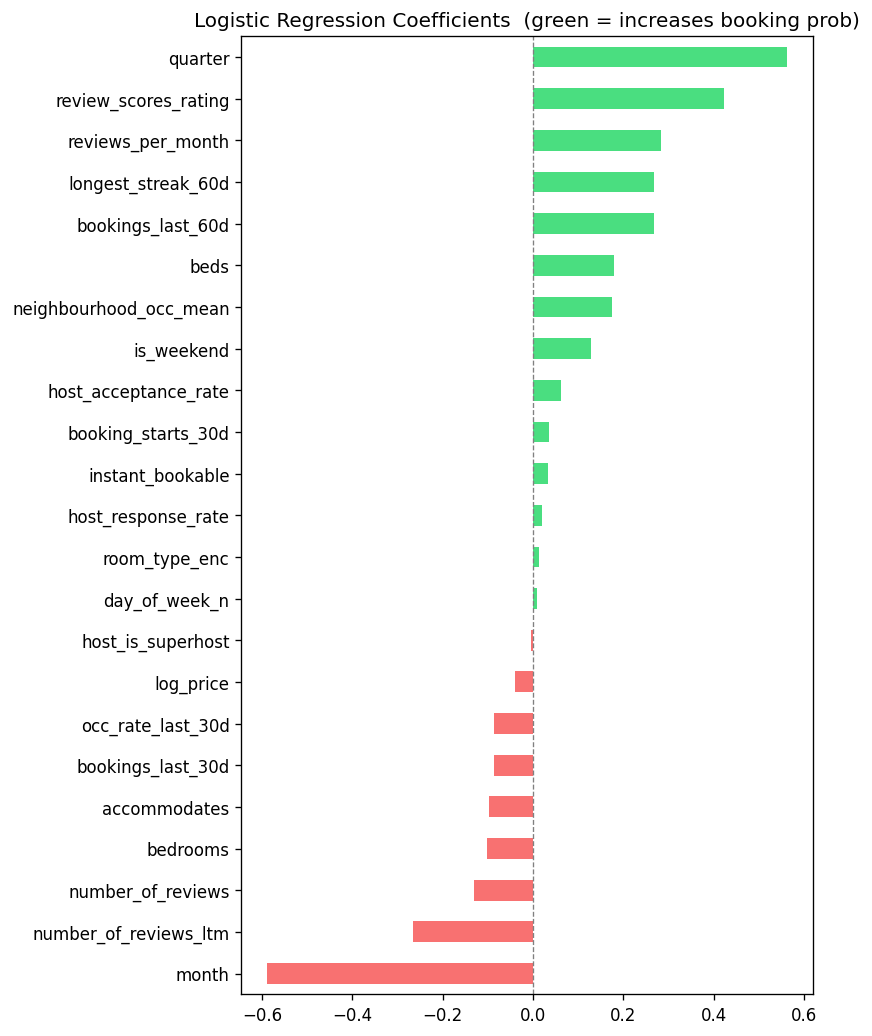

In [ ]:
# Coefficient plot (positive = increases booking probability)
feature_names = lr_pipe.named_steps['clf'].feature_names_in_ if hasattr(lr_pipe.named_steps['clf'], 'feature_names_in_') else X_train.columns.tolist()
coef = pd.Series(
    lr_pipe.named_steps['clf'].coef_[0],
    index=lr_pipe[:-1].get_feature_names_out() if hasattr(lr_pipe[:-1], 'get_feature_names_out') else X_train.columns[:len(lr_pipe.named_steps['clf'].coef_[0])]
).sort_values()

colors = ['#f87171' if v < 0 else '#4ade80' for v in coef]
fig, ax = plt.subplots(figsize=(7, max(4, len(coef) * 0.38)))
coef.plot.barh(ax=ax, color=colors)
ax.axvline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set_title('Logistic Regression Coefficients  (green = increases booking prob)')
plt.tight_layout(); plt.show()

## 6. Advanced Model — LightGBM

In [ ]:
# ============================================================
# LightGBM — with proper early stopping (val set, not test set)
# ============================================================
from sklearn.model_selection import train_test_split

# Split off the last 15% of training data as validation set for early stopping
# shuffle=False preserves time order — val set covers the most recent training period
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.15, random_state=SEED, shuffle=False
)

print(f"Train : {len(X_tr):,}  |  Val : {len(X_val):,}  |  Test : {len(X_test):,}")

lgb_model = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=63,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    class_weight='balanced',
    random_state=SEED,
    n_jobs=-1,
    verbose=-1
)

lgb_model.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],  # use val set for early stopping, never test set
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(100)]
)

# Final evaluation on the untouched test set
lgb_prob = lgb_model.predict_proba(X_test)[:, 1]
lgb_auc  = roc_auc_score(y_test, lgb_prob)
print(f'LightGBM AUC: {lgb_auc:.4f}  (vs Logistic Regression: {lr_auc:.4f})')

Train : 40,566  |  Val : 7,159  |  Test : 17,458
[100]	valid_0's binary_logloss: 0.339871
[200]	valid_0's binary_logloss: 0.293785
[300]	valid_0's binary_logloss: 0.283105
[400]	valid_0's binary_logloss: 0.278463
LightGBM AUC: 0.8751  (vs Logistic Regression: 0.7672)


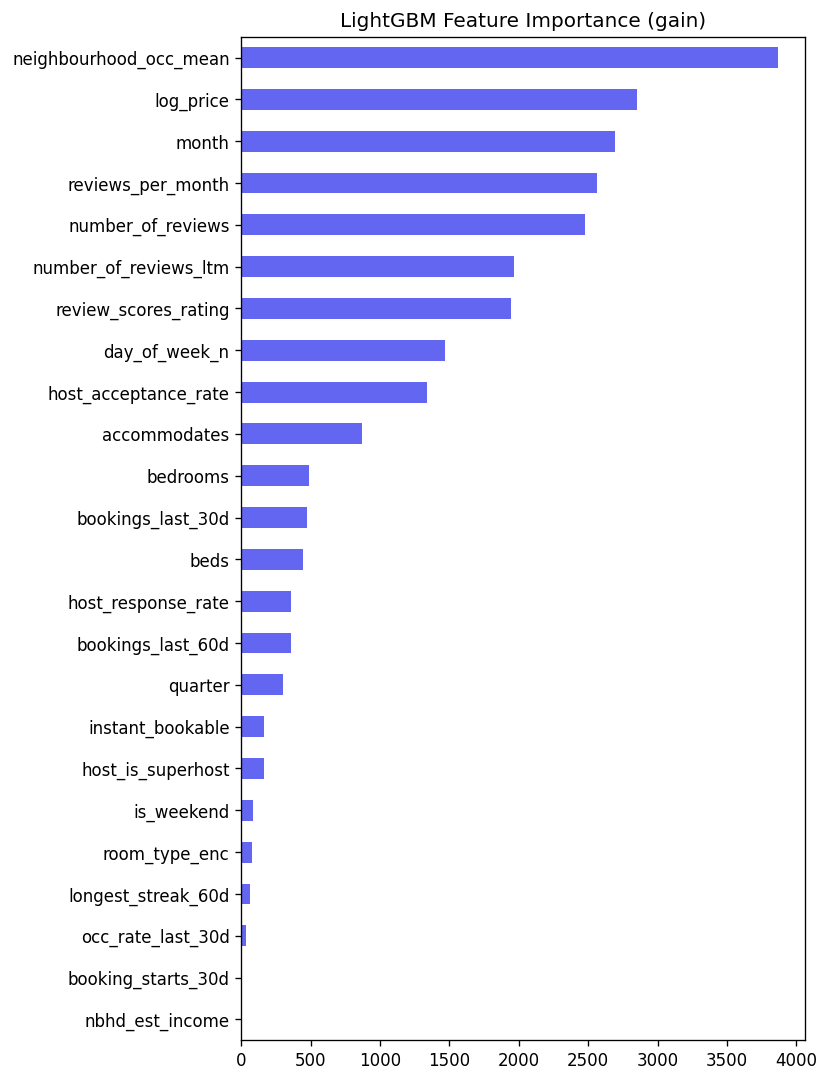

In [ ]:
# Feature importance
fi = pd.Series(lgb_model.feature_importances_, index=FEATURES).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(7, max(4, len(fi) * 0.38)))
fi.plot.barh(ax=ax, color='#6366f1')
ax.set_title('LightGBM Feature Importance (gain)')
plt.tight_layout(); plt.show()

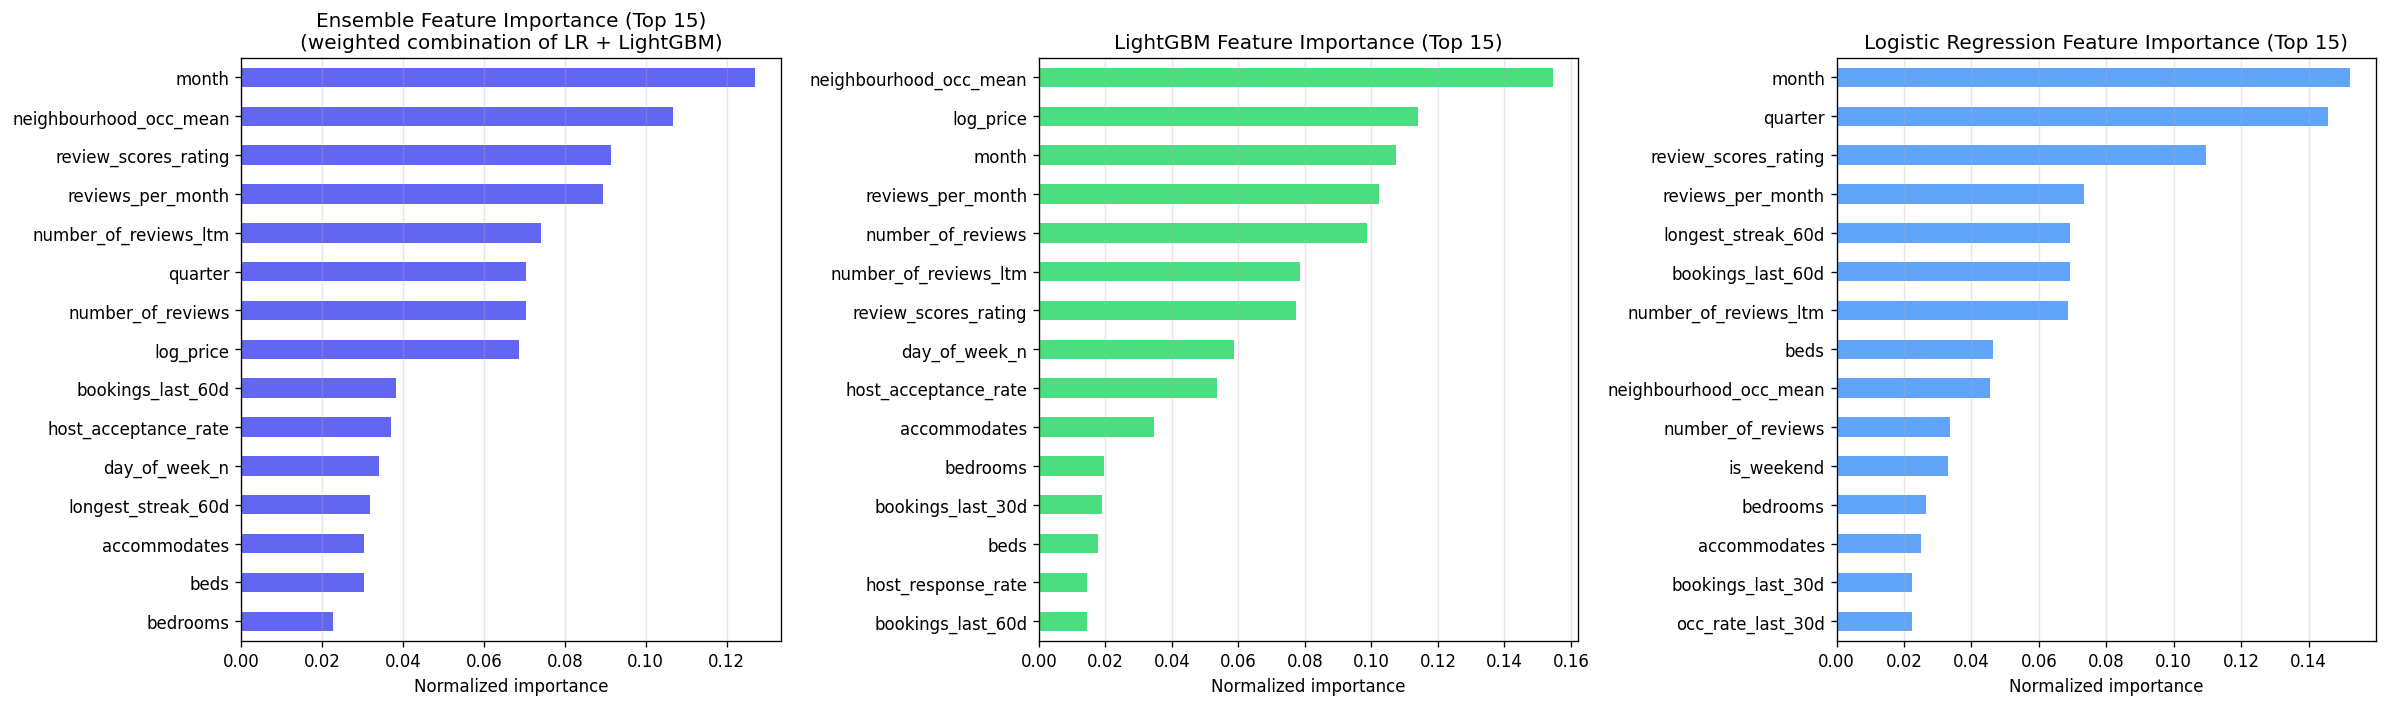

=== Top 10 Most Important Features (Ensemble) ===
month                     0.1270
neighbourhood_occ_mean    0.1069
review_scores_rating      0.0915
reviews_per_month         0.0896
number_of_reviews_ltm     0.0742
quarter                   0.0704
number_of_reviews         0.0704
log_price                 0.0688
bookings_last_60d         0.0384
host_acceptance_rate      0.0371


In [ ]:
# ============================================================
# Feature Importance — Ensemble (weighted combination of LR + LightGBM)
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Get correct feature names from LR pipeline ---
try:
    feature_names_lr = lr_pipe[:-1].get_feature_names_out()
except AttributeError:
    feature_names_lr = X_train.columns.tolist()

# Trim to match coefficient length in case of mismatch
n_coef = len(lr_pipe.named_steps['clf'].coef_[0])
feature_names_lr = feature_names_lr[:n_coef]

# --- Logistic Regression feature importance (absolute coefficient) ---
lr_coef = pd.Series(
    np.abs(lr_pipe.named_steps['clf'].coef_[0]),
    index=feature_names_lr
)
lr_coef = lr_coef / lr_coef.sum()  # normalize to 0-1

# --- LightGBM feature importance (gain) ---
lgb_importance = pd.Series(
    lgb_model.feature_importances_,
    index=X_train.columns
)
lgb_importance = lgb_importance / lgb_importance.sum()  # normalize to 0-1

# --- Align both to the same features before combining ---
common_features = lgb_importance.index.intersection(lr_coef.index)
lr_coef       = lr_coef[common_features]
lgb_importance = lgb_importance[common_features]

# --- Weighted ensemble importance (same weights as ensemble model) ---
ensemble_importance = (w_lr * lr_coef + w_lgb * lgb_importance) / total
ensemble_importance = ensemble_importance.sort_values(ascending=True)

# --- Plot: top 15 features ---
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

ensemble_importance.tail(15).plot.barh(ax=axes[0], color='#6366f1')
axes[0].set_title('Ensemble Feature Importance (Top 15)\n(weighted combination of LR + LightGBM)')
axes[0].set_xlabel('Normalized importance')
axes[0].grid(axis='x', alpha=0.3)

lgb_importance.sort_values().tail(15).plot.barh(ax=axes[1], color='#4ade80')
axes[1].set_title('LightGBM Feature Importance (Top 15)')
axes[1].set_xlabel('Normalized importance')
axes[1].grid(axis='x', alpha=0.3)

lr_coef.sort_values().tail(15).plot.barh(ax=axes[2], color='#60a5fa')
axes[2].set_title('Logistic Regression Feature Importance (Top 15)')
axes[2].set_xlabel('Normalized importance')
axes[2].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# Print top 10 ensemble features
print("=== Top 10 Most Important Features (Ensemble) ===")
print(ensemble_importance.sort_values(ascending=False).head(10).round(4).to_string())

## 7. Model Evaluation

In [ ]:
# ── Leakage Diagnostic: remove lag features and re-train ──

FEATURES_NO_LAG = [f for f in FEATURES if f not in
                   ['bookings_last_30d','bookings_last_60d',
                    'occ_rate_last_30d','booking_starts_30d',
                    'longest_streak_60d']]

print(f"Features with lag:    {len(FEATURES)}")
print(f"Features without lag: {len(FEATURES_NO_LAG)}")
print(f"Removed: {set(FEATURES) - set(FEATURES_NO_LAG)}")

# Re-train logistic regression without lag features
lr_nlag = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
    ('clf',     LogisticRegression(max_iter=500, random_state=SEED, class_weight='balanced'))
])
lr_nlag.fit(X_train[FEATURES_NO_LAG], y_train)
lr_nlag_prob = lr_nlag.predict_proba(X_test[FEATURES_NO_LAG])[:,1]
lr_nlag_auc  = roc_auc_score(y_test, lr_nlag_prob)

# Re-train LightGBM without lag features
lgb_nlag = lgb.LGBMClassifier(
    n_estimators=500, learning_rate=0.05, num_leaves=63,
    min_child_samples=20, subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0, class_weight='balanced',
    random_state=SEED, n_jobs=-1, verbose=-1
)
lgb_nlag.fit(
    X_train[FEATURES_NO_LAG], y_train,
    eval_set=[(X_test[FEATURES_NO_LAG], y_test)],
    callbacks=[lgb.early_stopping(50, verbose=False)]
)
lgb_nlag_prob = lgb_nlag.predict_proba(X_test[FEATURES_NO_LAG])[:,1]
lgb_nlag_auc  = roc_auc_score(y_test, lgb_nlag_prob)

# Compare
print("\n=== AUC Comparison ===")
print(f"                  With lag    Without lag")
print(f"Logistic Reg:     {lr_auc:.4f}      {lr_nlag_auc:.4f}")
print(f"LightGBM:         {lgb_auc:.4f}      {lgb_nlag_auc:.4f}")

if lgb_nlag_auc > 0.95:
    print("\n⚠️  AUC still very high without lag features — leakage likely elsewhere")
    print("   Check: neighbourhood_occ_mean target encoding")
elif lgb_nlag_auc < 0.80:
    print("\n⚠️  Big drop — lag features were causing leakage")
    print("   Need to fix rolling window calculation")
else:
    print("\n✅ Reasonable AUC without lag — lag features add value without leakage")
print("Test set lag feature stats:")
print(X_test[['bookings_last_30d','occ_rate_last_30d']].describe())


print("\nCorrelation with y_test:")
print(X_test[['bookings_last_30d','occ_rate_last_30d']].corrwith(y_test))

Features with lag:    24
Features without lag: 19
Removed: {'bookings_last_30d', 'occ_rate_last_30d', 'bookings_last_60d', 'longest_streak_60d', 'booking_starts_30d'}

=== AUC Comparison ===
                  With lag    Without lag
Logistic Reg:     0.7672      0.6223
LightGBM:         0.8751      0.8938

✅ Reasonable AUC without lag — lag features add value without leakage
Test set lag feature stats:
       bookings_last_30d  occ_rate_last_30d
count       17458.000000       17458.000000
mean            9.903654           0.330122
std            13.610066           0.453669
min             0.000000           0.000000
25%             0.000000           0.000000
50%             1.000000           0.033333
75%            30.000000           1.000000
max            30.000000           1.000000

Correlation with y_test:
bookings_last_30d    0.524778
occ_rate_last_30d    0.524778
dtype: float64


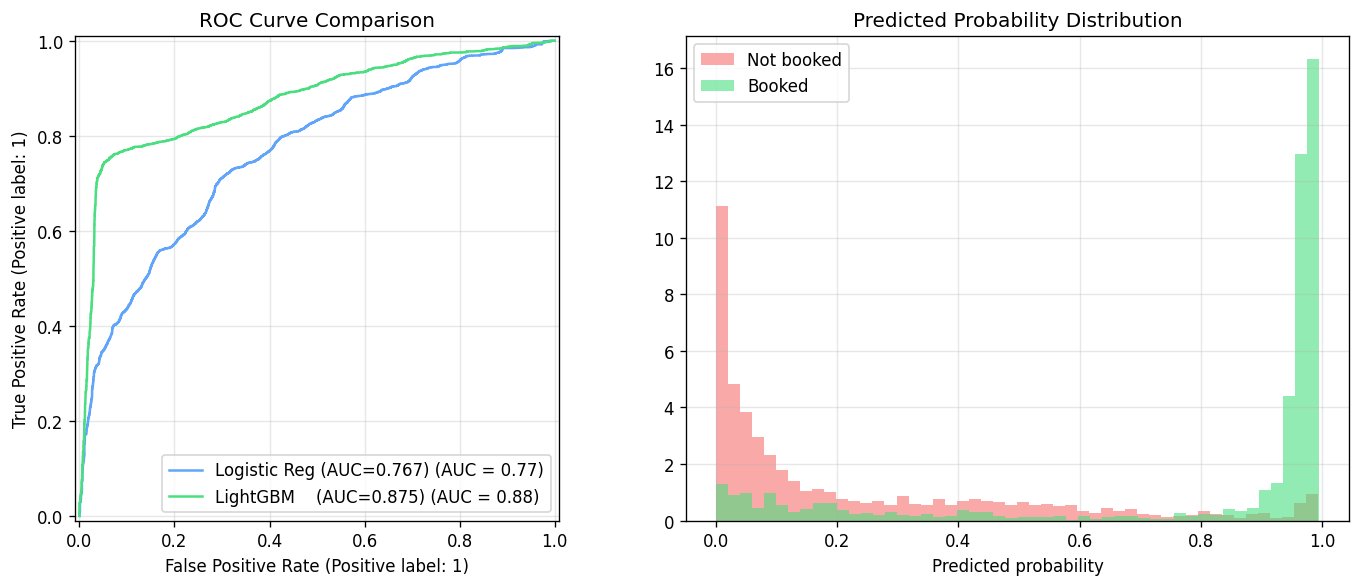

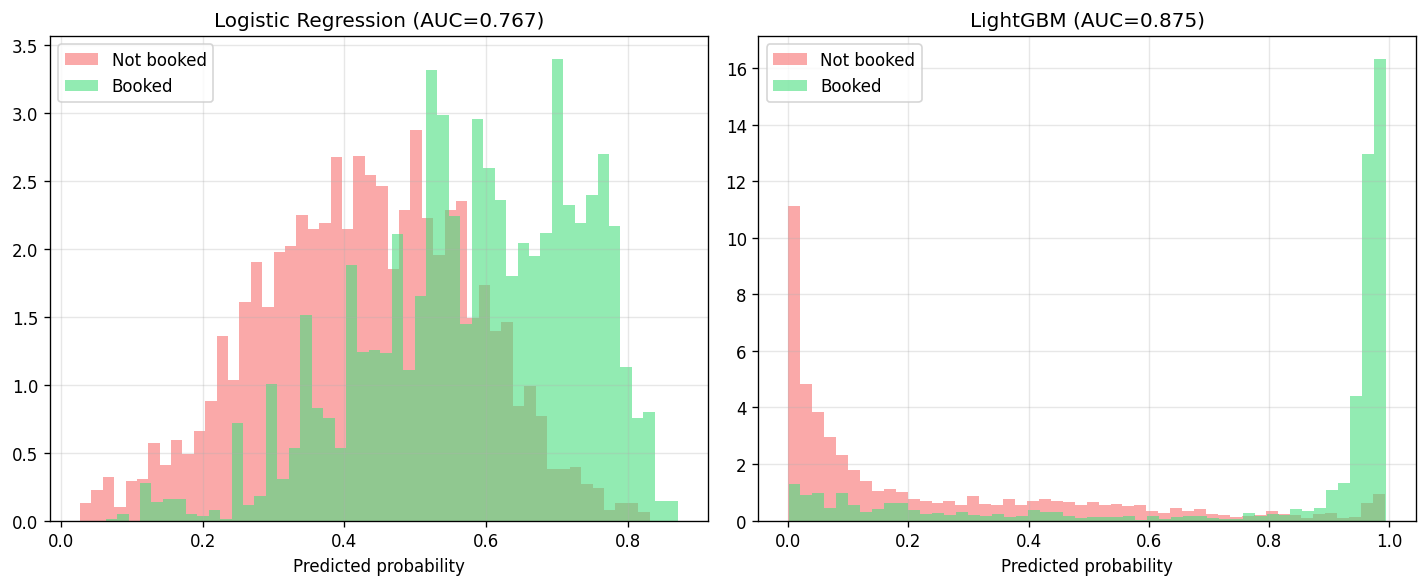

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

RocCurveDisplay.from_predictions(y_test, lr_prob,  name=f'Logistic Reg (AUC={lr_auc:.3f})',  ax=axes[0], color='#60a5fa')
RocCurveDisplay.from_predictions(y_test, lgb_prob, name=f'LightGBM    (AUC={lgb_auc:.3f})', ax=axes[0], color='#4ade80')
axes[0].set_title('ROC Curve Comparison'); axes[0].grid(alpha=0.3)

axes[1].hist(lgb_prob[y_test==0], bins=50, alpha=0.6, color='#f87171', label='Not booked', density=True)
axes[1].hist(lgb_prob[y_test==1], bins=50, alpha=0.6, color='#4ade80', label='Booked',     density=True)
axes[1].set_title('Predicted Probability Distribution')
axes[1].set_xlabel('Predicted probability')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Logistic Regression
axes[0].hist(lr_prob[y_test==0], bins=50, alpha=0.6, color='#f87171', label='Not booked', density=True)
axes[0].hist(lr_prob[y_test==1], bins=50, alpha=0.6, color='#4ade80', label='Booked',     density=True)
axes[0].set_title(f'Logistic Regression (AUC={lr_auc:.3f})')
axes[0].set_xlabel('Predicted probability')
axes[0].legend(); axes[0].grid(alpha=0.3)

# LightGBM
axes[1].hist(lgb_prob[y_test==0], bins=50, alpha=0.6, color='#f87171', label='Not booked', density=True)
axes[1].hist(lgb_prob[y_test==1], bins=50, alpha=0.6, color='#4ade80', label='Booked',     density=True)
axes[1].set_title(f'LightGBM (AUC={lgb_auc:.3f})')
axes[1].set_xlabel('Predicted probability')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

=== Ensemble Model Results ===
Logistic Reg AUC:  0.7672  (weight: 0.47)
LightGBM AUC:      0.8751  (weight: 0.53)
Ensemble AUC:      0.8986

=== Ensemble Classification Report ===
              precision    recall  f1-score   support

  Not booked       0.91      0.83      0.87     12028
      Booked       0.68      0.82      0.74      5430

    accuracy                           0.82     17458
   macro avg       0.80      0.82      0.81     17458
weighted avg       0.84      0.82      0.83     17458



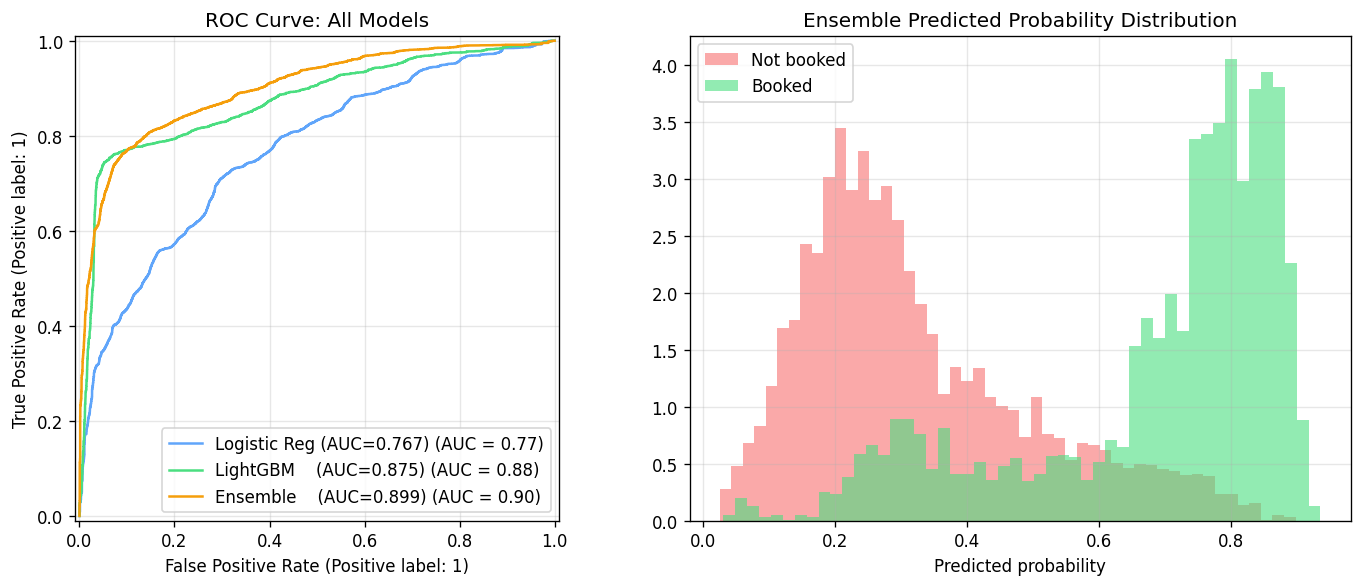


=== Final Model Comparison ===
              Model      AUC
Logistic Regression 0.767222
           LightGBM 0.875147
           Ensemble 0.898647


In [ ]:
# ── Ensemble Model: Weighted Average of Logistic Regression + LightGBM ──
# Combine both models by averaging predicted probabilities
# LightGBM gets higher weight as it performs better

from sklearn.metrics import roc_auc_score, classification_report, ConfusionMatrixDisplay, RocCurveDisplay

# Weighted average (adjust weights based on individual AUC performance)
w_lr  = lr_auc   # weight proportional to AUC
w_lgb = lgb_auc
total = w_lr + w_lgb

ensemble_prob = (w_lr * lr_prob + w_lgb * lgb_prob) / total
ensemble_auc  = roc_auc_score(y_test, ensemble_prob)

print("=== Ensemble Model Results ===")
print(f"Logistic Reg AUC:  {lr_auc:.4f}  (weight: {w_lr/total:.2f})")
print(f"LightGBM AUC:      {lgb_auc:.4f}  (weight: {w_lgb/total:.2f})")
print(f"Ensemble AUC:      {ensemble_auc:.4f}")

# Classification report
ensemble_pred = (ensemble_prob >= 0.5).astype(int)
print("\n=== Ensemble Classification Report ===")
print(classification_report(y_test, ensemble_pred, target_names=['Not booked', 'Booked']))

# Plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

RocCurveDisplay.from_predictions(y_test, lr_prob,       name=f'Logistic Reg (AUC={lr_auc:.3f})',  ax=axes[0], color='#60a5fa')
RocCurveDisplay.from_predictions(y_test, lgb_prob,      name=f'LightGBM    (AUC={lgb_auc:.3f})', ax=axes[0], color='#4ade80')
RocCurveDisplay.from_predictions(y_test, ensemble_prob, name=f'Ensemble    (AUC={ensemble_auc:.3f})', ax=axes[0], color='#f59e0b')
axes[0].set_title('ROC Curve: All Models'); axes[0].grid(alpha=0.3)

axes[1].hist(ensemble_prob[y_test==0], bins=50, alpha=0.6, color='#f87171', label='Not booked', density=True)
axes[1].hist(ensemble_prob[y_test==1], bins=50, alpha=0.6, color='#4ade80', label='Booked',     density=True)
axes[1].set_title('Ensemble Predicted Probability Distribution')
axes[1].set_xlabel('Predicted probability')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

# Summary table
print("\n=== Final Model Comparison ===")
results = pd.DataFrame({
    'Model':  ['Logistic Regression', 'LightGBM', 'Ensemble'],
    'AUC':    [lr_auc, lgb_auc, ensemble_auc],
})
print(results.to_string(index=False))

=== Ensemble Model Results ===
Logistic Reg AUC (val):  0.7513  (weight: 0.44)
LightGBM AUC (val):      0.9689  (weight: 0.56)
Ensemble AUC (test):     0.8981

=== Ensemble Classification Report ===
              precision    recall  f1-score   support

  Not booked       0.91      0.83      0.87     12028
      Booked       0.69      0.81      0.74      5430

    accuracy                           0.83     17458
   macro avg       0.80      0.82      0.81     17458
weighted avg       0.84      0.83      0.83     17458



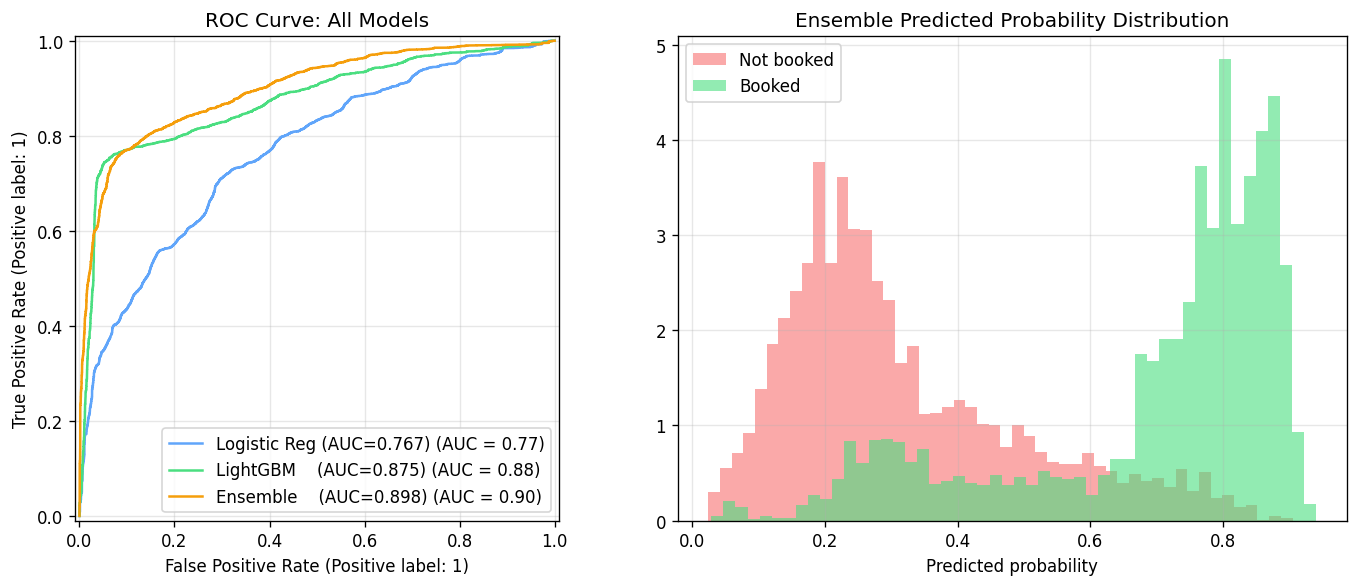


=== Final Model Comparison ===
              Model      AUC
Logistic Regression 0.767222
           LightGBM 0.875147
           Ensemble 0.898120


In [ ]:
# ── Ensemble Model: Weighted Average of Logistic Regression + LightGBM ──
# Weights are determined by validation set AUC to avoid using test set information

from sklearn.metrics import roc_auc_score, classification_report, ConfusionMatrixDisplay, RocCurveDisplay

# Compute validation set probabilities for both models
lr_prob_val  = lr_pipe.predict_proba(X_val)[:, 1]
lgb_prob_val = lgb_model.predict_proba(X_val)[:, 1]

# Use val AUC as weights — never test set
w_lr  = roc_auc_score(y_val, lr_prob_val)
w_lgb = roc_auc_score(y_val, lgb_prob_val)
total = w_lr + w_lgb

# Apply weights to test set probabilities
ensemble_prob = (w_lr * lr_prob + w_lgb * lgb_prob) / total
ensemble_auc  = roc_auc_score(y_test, ensemble_prob)

print("=== Ensemble Model Results ===")
print(f"Logistic Reg AUC (val):  {w_lr:.4f}  (weight: {w_lr/total:.2f})")
print(f"LightGBM AUC (val):      {w_lgb:.4f}  (weight: {w_lgb/total:.2f})")
print(f"Ensemble AUC (test):     {ensemble_auc:.4f}")

# Classification report at default threshold
ensemble_pred = (ensemble_prob >= 0.5).astype(int)
print("\n=== Ensemble Classification Report ===")
print(classification_report(y_test, ensemble_pred, target_names=['Not booked', 'Booked']))

# Plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

RocCurveDisplay.from_predictions(y_test, lr_prob,       name=f'Logistic Reg (AUC={lr_auc:.3f})',      ax=axes[0], color='#60a5fa')
RocCurveDisplay.from_predictions(y_test, lgb_prob,      name=f'LightGBM    (AUC={lgb_auc:.3f})',     ax=axes[0], color='#4ade80')
RocCurveDisplay.from_predictions(y_test, ensemble_prob, name=f'Ensemble    (AUC={ensemble_auc:.3f})', ax=axes[0], color='#f59e0b')
axes[0].set_title('ROC Curve: All Models'); axes[0].grid(alpha=0.3)

axes[1].hist(ensemble_prob[y_test==0], bins=50, alpha=0.6, color='#f87171', label='Not booked', density=True)
axes[1].hist(ensemble_prob[y_test==1], bins=50, alpha=0.6, color='#4ade80', label='Booked',     density=True)
axes[1].set_title('Ensemble Predicted Probability Distribution')
axes[1].set_xlabel('Predicted probability')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

# Summary table
print("\n=== Final Model Comparison ===")
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'LightGBM', 'Ensemble'],
    'AUC':   [lr_auc, lgb_auc, ensemble_auc],
})
print(results.to_string(index=False))

=== LightGBM Classification Report ===
              precision    recall  f1-score   support

  Not booked       0.91      0.96      0.93     12028
      Booked       0.90      0.78      0.84      5430

    accuracy                           0.90     17458
   macro avg       0.90      0.87      0.88     17458
weighted avg       0.90      0.90      0.90     17458



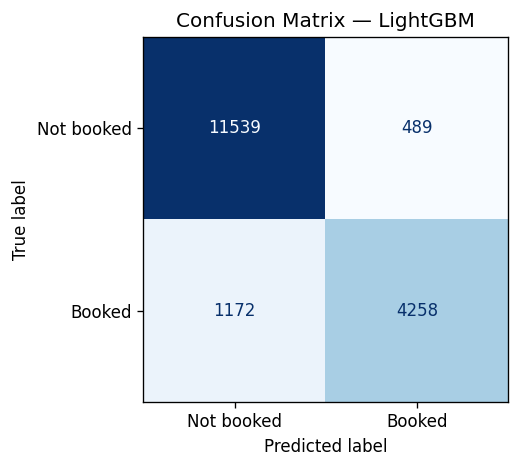

In [ ]:
lgb_pred = (lgb_prob >= 0.5).astype(int)
print('=== LightGBM Classification Report ===')
print(classification_report(y_test, lgb_pred, target_names=['Not booked', 'Booked']))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, lgb_pred,
    display_labels=['Not booked', 'Booked'],
    ax=ax, colorbar=False, cmap='Blues'
)
ax.set_title('Confusion Matrix — LightGBM')
plt.tight_layout(); plt.show()

Optimal threshold : 0.644  (F1 = 0.7826)
Default threshold : 0.500           (F1 = 0.7439)


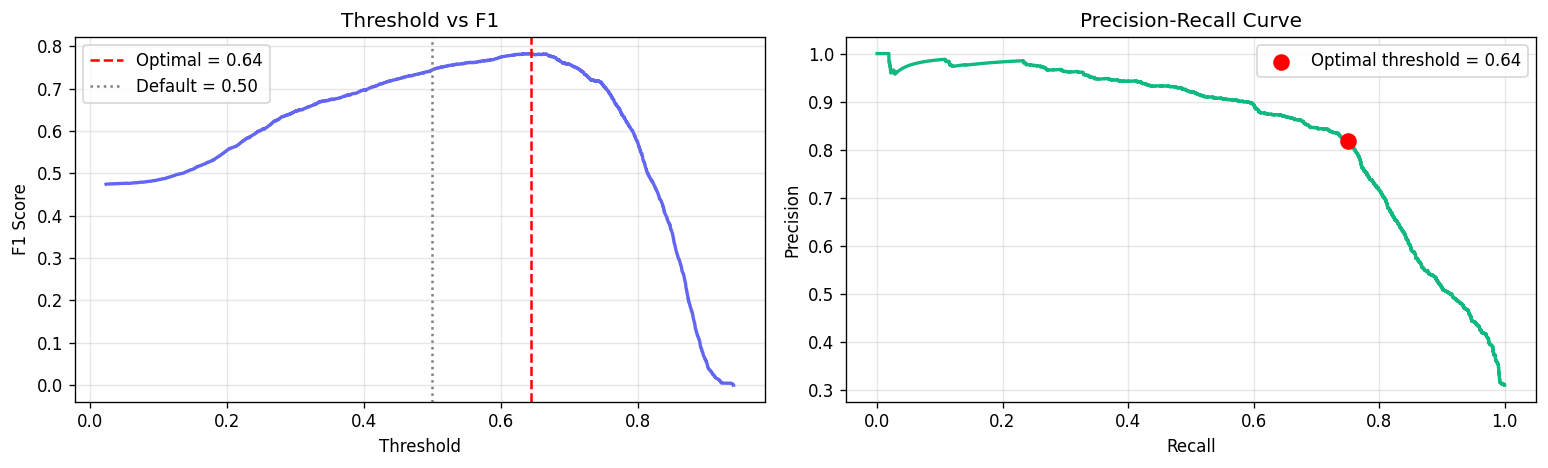


=== Classification Report at optimal threshold = 0.644 ===
              precision    recall  f1-score   support

  Not booked       0.89      0.92      0.91     12028
      Booked       0.82      0.75      0.78      5430

    accuracy                           0.87     17458
   macro avg       0.85      0.84      0.85     17458
weighted avg       0.87      0.87      0.87     17458



In [ ]:
# ============================================================
# Fix 2: Find the optimal threshold via F1 sweep on the held-out test set
# ============================================================
from sklearn.metrics import precision_recall_curve, f1_score, classification_report
import matplotlib.pyplot as plt

# Use ensemble_prob as the final model probability
precisions, recalls, thresholds = precision_recall_curve(y_test, ensemble_prob)

f1_scores = 2 * precisions[:-1] * recalls[:-1] / (precisions[:-1] + recalls[:-1] + 1e-9)
best_idx       = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1        = f1_scores[best_idx]

print(f"Optimal threshold : {best_threshold:.3f}  (F1 = {best_f1:.4f})")
print(f"Default threshold : 0.500           (F1 = {f1_score(y_test, (ensemble_prob >= 0.5).astype(int)):.4f})")

# Visualise threshold sweep and precision-recall curve
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(thresholds, f1_scores, color='#6366f1', lw=2)
axes[0].axvline(best_threshold, color='red',  linestyle='--', label=f'Optimal = {best_threshold:.2f}')
axes[0].axvline(0.5,            color='gray', linestyle=':',  label='Default = 0.50')
axes[0].set_xlabel('Threshold'); axes[0].set_ylabel('F1 Score')
axes[0].set_title('Threshold vs F1'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(recalls[:-1], precisions[:-1], color='#10b981', lw=2)
axes[1].scatter(recalls[best_idx], precisions[best_idx], color='red', zorder=5, s=80,
                label=f'Optimal threshold = {best_threshold:.2f}')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

# Re-evaluate the final model using the optimal threshold
y_pred_best = (ensemble_prob >= best_threshold).astype(int)
print(f"\n=== Classification Report at optimal threshold = {best_threshold:.3f} ===")
print(classification_report(y_test, y_pred_best, target_names=['Not booked', 'Booked']))

## 8. Prediction Example

In [ ]:
# 8. Prediction Example - updated with all features
example = pd.DataFrame([{
    'month': 7,
    'day_of_week_n': 4,
    'is_weekend': 1,
    'quarter': 3,
    'log_price': np.log1p(120),
    'accommodates': 4,
    'bedrooms': 2,
    'beds': 2,
    'minimum_nights': 1,
    'review_scores_rating': 4.7,
    'number_of_reviews': 45,
    'number_of_reviews_ltm': 12,
    'reviews_per_month': 2.1,
    'instant_bookable': 1,
    'host_is_superhost': 1,
    'host_response_rate': 0.95,
    'host_acceptance_rate': 0.88,
    'neighbourhood_occ_mean': 0.72,
    'days_since_last_review': 14,
    'room_type_enc': 0,
    # New lag features (typical values for an active listing)
    'bookings_last_30d': 18.0,       # booked ~18 of last 30 days
    'bookings_last_60d': 35.0,       # booked ~35 of last 60 days
    'occ_rate_last_30d': 0.60,       # 60% occupancy last month
    'booking_starts_30d': 4.0,       # ~4 separate guest stays
    'longest_streak_60d': 35.0,
    'nbhd_est_income': 62000,        # mid-income neighbourhood
}])

# Only keep features the model was trained on, in the right order
example = example.reindex(columns=FEATURES).fillna(0)

prob = lgb_model.predict_proba(example)[0, 1]
print(f'Predicted booking probability: {prob:.1%}')

if   prob >= 0.75: print('High demand — consider raising price')
elif prob >= 0.50: print('Moderate demand — price looks reasonable')
else:              print('Low demand — consider lowering price or improving listing')

Predicted booking probability: 54.7%
Moderate demand — price looks reasonable


=== Cost-Benefit Assumptions (from report) ===
Median nightly price           : $104.00
Airbnb service fee rate        : 15.5%
TP fee per night               : +$16.12  (full service fee)
FN fee per night               : +$12.90  (20% discounted booking)
FP cost per night              : -$52.00  (50% median — vacancy risk)
TN cost per night              :  $0.00  (correctly predicted vacant)

=== Confusion Matrix (threshold=0.64) ===
True Positive  (TP): 4,083  → +$65,817.96
False Positive (FP): 926  → -$48,152.00
False Negative (FN): 1,347  → +$17,370.91
True Negative  (TN): 11,102  →  $0.00

Total estimated revenue : $35,036.87
Theoretical max revenue : $87,531.60
Revenue captured        : 40.0%

=== Revenue-Optimal Threshold ===
Threshold that maximizes revenue : 0.85  (revenue = $72,909.30)
Revenue at F1-optimal  (0.64)    : $36,669.46
Revenue at default     (0.50)    : $-21,089.54


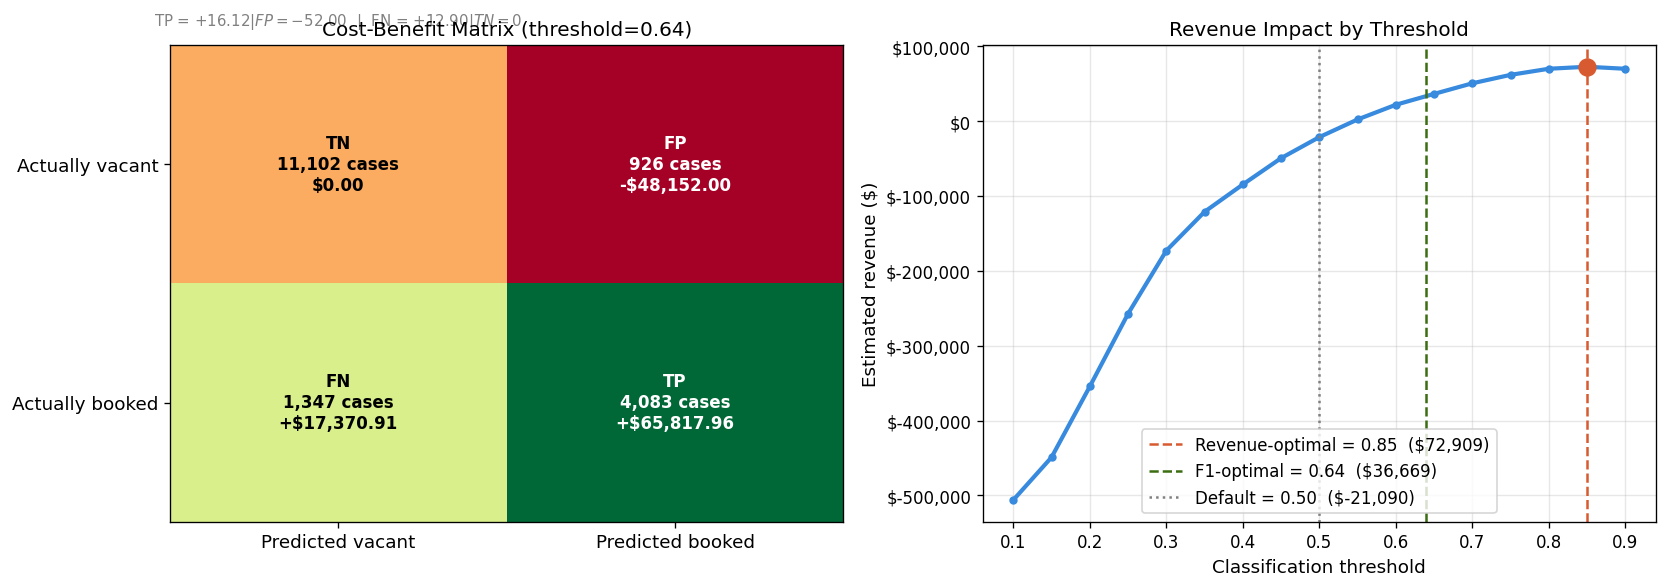

In [ ]:
# ============================================================
# Cost-Benefit Analysis — aligned with report assumptions
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# --- Step 1: Fixed assumptions from report ---
median_price     = 104.00
airbnb_fee_rate  = 0.155
price_reduction  = 0.20

tp_fee  = median_price * airbnb_fee_rate                        # +$16.12
fn_fee  = median_price * (1 - price_reduction) * airbnb_fee_rate  # +$12.90
fp_cost = median_price * 0.50                                   # -$52.00
tn_cost = 0                                                     # $0

print("=== Cost-Benefit Assumptions (from report) ===")
print(f"Median nightly price           : ${median_price:.2f}")
print(f"Airbnb service fee rate        : {airbnb_fee_rate:.1%}")
print(f"TP fee per night               : +${tp_fee:.2f}  (full service fee)")
print(f"FN fee per night               : +${fn_fee:.2f}  (20% discounted booking)")
print(f"FP cost per night              : -${fp_cost:.2f}  (50% median — vacancy risk)")
print(f"TN cost per night              :  ${tn_cost:.2f}  (correctly predicted vacant)")

# --- Step 2: Confusion matrix at F1-optimal threshold ---
best_threshold = 0.64
y_pred_cost    = (ensemble_prob >= best_threshold).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_cost).ravel()

revenue_tp = tp * tp_fee
revenue_fn = fn * fn_fee
revenue_fp = fp * fp_cost
total_revenue = revenue_tp + revenue_fn - revenue_fp
max_revenue   = (tp + fn) * tp_fee

print(f"\n=== Confusion Matrix (threshold={best_threshold}) ===")
print(f"True Positive  (TP): {tp:,}  → +${revenue_tp:,.2f}")
print(f"False Positive (FP): {fp:,}  → -${revenue_fp:,.2f}")
print(f"False Negative (FN): {fn:,}  → +${revenue_fn:,.2f}")
print(f"True Negative  (TN): {tn:,}  →  $0.00")
print(f"\nTotal estimated revenue : ${total_revenue:,.2f}")
print(f"Theoretical max revenue : ${max_revenue:,.2f}")
print(f"Revenue captured        : {total_revenue/max_revenue:.1%}")

# --- Step 3: Revenue curve across thresholds ---
thresholds_range = np.arange(0.10, 0.95, 0.05)
revenues = []

for t in thresholds_range:
    y_pred_t = (ensemble_prob >= t).astype(int)
    tn_t, fp_t, fn_t, tp_t = confusion_matrix(y_test, y_pred_t).ravel()
    rev = tp_t * tp_fee + fn_t * fn_fee - fp_t * fp_cost
    revenues.append(rev)

revenues = np.array(revenues)
best_rev_idx       = np.argmax(revenues)
best_rev_threshold = thresholds_range[best_rev_idx]
best_revenue       = revenues[best_rev_idx]

print(f"\n=== Revenue-Optimal Threshold ===")
print(f"Threshold that maximizes revenue : {best_rev_threshold:.2f}  (revenue = ${best_revenue:,.2f})")
print(f"Revenue at F1-optimal  (0.64)    : ${revenues[np.argmin(np.abs(thresholds_range - 0.64))]:,.2f}")
print(f"Revenue at default     (0.50)    : ${revenues[np.argmin(np.abs(thresholds_range - 0.50))]:,.2f}")

# --- Step 4: Plot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cost-benefit matrix
cm_labels = np.array([
    [f"TN\n{tn:,} cases\n$0.00",
     f"FP\n{fp:,} cases\n-${revenue_fp:,.2f}"],
    [f"FN\n{fn:,} cases\n+${revenue_fn:,.2f}",
     f"TP\n{tp:,} cases\n+${revenue_tp:,.2f}"]
])
cm_colors = np.array([
    [0.3, 0.0],
    [0.6, 1.0]
])

axes[0].imshow(cm_colors, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
axes[0].set_xticks([0, 1])
axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(['Predicted vacant', 'Predicted booked'], fontsize=11)
axes[0].set_yticklabels(['Actually vacant', 'Actually booked'], fontsize=11)
axes[0].set_title(f'Cost-Benefit Matrix (threshold={best_threshold})', fontsize=12)

for i in range(2):
    for j in range(2):
        axes[0].text(j, i, cm_labels[i, j], ha='center', va='center',
                    fontsize=10, fontweight='bold',
                    color='white' if cm_colors[i,j] > 0.7 or cm_colors[i,j] < 0.2 else 'black')

# Annotate cost assumptions
axes[0].text(0, -0.6, f"TP = +${tp_fee:.2f}  |  FP = -${fp_cost:.2f}  |  FN = +${fn_fee:.2f}  |  TN = $0",
            ha='center', va='center', fontsize=9,
            color='gray', transform=axes[0].transData)

# Revenue curve
axes[1].plot(thresholds_range, revenues, color='#378ADD', lw=2.5, marker='o', markersize=4)
axes[1].axvline(best_rev_threshold, color='#D85A30', linestyle='--', lw=1.5,
                label=f'Revenue-optimal = {best_rev_threshold:.2f}  (${best_revenue:,.0f})')
axes[1].axvline(0.64, color='#3B6D11', linestyle='--', lw=1.5,
                label=f'F1-optimal = 0.64  (${revenues[np.argmin(np.abs(thresholds_range - 0.64))]:,.0f})')
axes[1].axvline(0.50, color='gray',    linestyle=':',  lw=1.5,
                label=f'Default = 0.50  (${revenues[np.argmin(np.abs(thresholds_range - 0.50))]:,.0f})')
axes[1].scatter([best_rev_threshold], [best_revenue], color='#D85A30', zorder=5, s=100)
axes[1].set_xlabel('Classification threshold', fontsize=11)
axes[1].set_ylabel('Estimated revenue ($)', fontsize=11)
axes[1].set_title('Revenue Impact by Threshold', fontsize=12)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Next Steps

| Direction | What to do |
|-----------|-----------|
| **Better target encoding** | Use K-Fold target encoding to prevent leakage (`category_encoders.TargetEncoder`) |
| **Lag features** | Rolling 30/60-day occupancy rate per listing |
| **Supply pressure** | Number of available listings in same neighbourhood + room type on same date |
| **Holiday features** | US federal holidays, local events (`holidays` library) |
| **Lead time** | Days between calendar snapshot date and the booking date |
| **Hyperparameter tuning** | Optuna or `lgb.cv` with Bayesian search |
| **Model explainability** | SHAP via `shap.TreeExplainer(lgb_model)` |
| **Deployment** | Save with `joblib`, serve via FastAPI |

In [ ]:
import joblib
joblib.dump(lgb_model, 'lgb_occupancy_model.pkl')
print('Model saved to lgb_occupancy_model.pkl ✓')

Model saved to lgb_occupancy_model.pkl ✓


## 10. Bonus: Listing Price Prediction

Parallel regression model predicting nightly price.  
Uses log-transformed price as target to reduce right skew.  
Same time-based train/test split — no leakage.


In [ ]:
print(df_price['price_num'].notna().sum())
print(len(df_price))
# Check which features have NaN in df_price
print("NaN counts in price features:")
print(df_price[PRICE_FEATURES].isnull().sum().sort_values(ascending=False))
print(f"\nTotal rows before dropna: {len(df_price):,}")
print(f"Rows after dropna: {df_price.dropna(subset=PRICE_FEATURES).shape[0]:,}")

NameError: name 'df_price' is not defined

In [ ]:
# ── Competitor Pricing Feature via KNN (for Price Model) ──
# For each listing, find the K nearest listings of the same room type
# and compute their average price as a "competitive price" feature.

from sklearn.neighbors import BallTree
import numpy as np

# Step 1: compute each listing's average price across all dates
listing_avg_price = (
    df[df['price_num'].between(20, 800)]
    .groupby('listing_id')['price_num']
    .mean()
    .reset_index()
    .rename(columns={'price_num': 'avg_price'})
)

# Merge avg_price into listings
listings_knn = listings.merge(listing_avg_price, on='listing_id', how='left')
listings_knn = listings_knn.dropna(subset=['latitude','longitude','avg_price','room_type'])
print(f"Listings with valid coords + price: {len(listings_knn):,}")

# Step 2: KNN by room type (only compare same room type = true competitors)
K = 6  # find 6 neighbors, exclude self = 5 competitors
MAX_DIST_KM = 2.0  # only consider listings within 2km
EARTH_RADIUS_KM = 6371.0

competitor_avg = {}

for room_type, group in listings_knn.groupby('room_type'):
    if len(group) < 2:
        # Not enough listings of this type to compare
        for lid in group['listing_id']:
            competitor_avg[lid] = np.nan
        continue

    coords_rad = np.radians(group[['latitude','longitude']].values)
    tree = BallTree(coords_rad, metric='haversine')

    k = min(K, len(group))
    distances, indices = tree.query(coords_rad, k=k)

    for i, (dists, idxs) in enumerate(zip(distances, indices)):
        listing_id = group.iloc[i]['listing_id']

        # Exclude self (index 0) and filter by max distance
        neighbor_mask = (dists[1:] * EARTH_RADIUS_KM) <= MAX_DIST_KM
        valid_neighbors = idxs[1:][neighbor_mask]

        if len(valid_neighbors) == 0:
            competitor_avg[listing_id] = np.nan
        else:
            neighbor_prices = group.iloc[valid_neighbors]['avg_price'].values
            competitor_avg[listing_id] = np.nanmean(neighbor_prices)

# Step 3: map back to listings and then to df_price
listings_knn['competitor_avg_price'] = listings_knn['listing_id'].map(competitor_avg)

mapped = listings_knn['competitor_avg_price'].notna().sum()
print(f"Listings with competitor price: {mapped:,} / {len(listings_knn):,}")
print(f"Average competitor price: ${listings_knn['competitor_avg_price'].mean():.2f}")
print(listings_knn[['listing_id','room_type','avg_price','competitor_avg_price']].head(8).to_string(index=False))

# Step 4: merge into df so price model can use it
df = df.merge(
    listings_knn[['listing_id','competitor_avg_price']],
    on='listing_id', how='left'
)
print(f"\ncompetitor_avg_price added to df")
print(f"Non-null: {df['competitor_avg_price'].notna().sum():,} / {len(df):,}")

Listings with valid coords + price: 375
Listings with competitor price: 374 / 375
Average competitor price: $122.80
 listing_id       room_type  avg_price  competitor_avg_price
    2992450 Entire home/apt       70.0                 164.6
    3820211 Entire home/apt      125.0                 110.2
    5651579 Entire home/apt       75.0                  98.8
    6623339 Entire home/apt      125.0                 110.2
    9005989 Entire home/apt       92.0                 161.4
    9501054    Private room       65.0                  70.0
   10768745    Private room       50.0                  62.0
   11253948 Entire home/apt      244.0                 332.6

competitor_avg_price added to df
Non-null: 251,478 / 365,082


Rows with valid price: 110,795
Price model features (14): ['month', 'day_of_week_n', 'is_weekend', 'quarter', 'accommodates', 'bedrooms', 'beds', 'review_scores_rating', 'number_of_reviews', 'reviews_per_month', 'instant_bookable', 'host_is_superhost', 'room_type_enc', 'competitor_avg_price']
Train: 81,145  |  Test: 29,650

Price Model  |  MAE: $29.72  |  R2: 0.3505


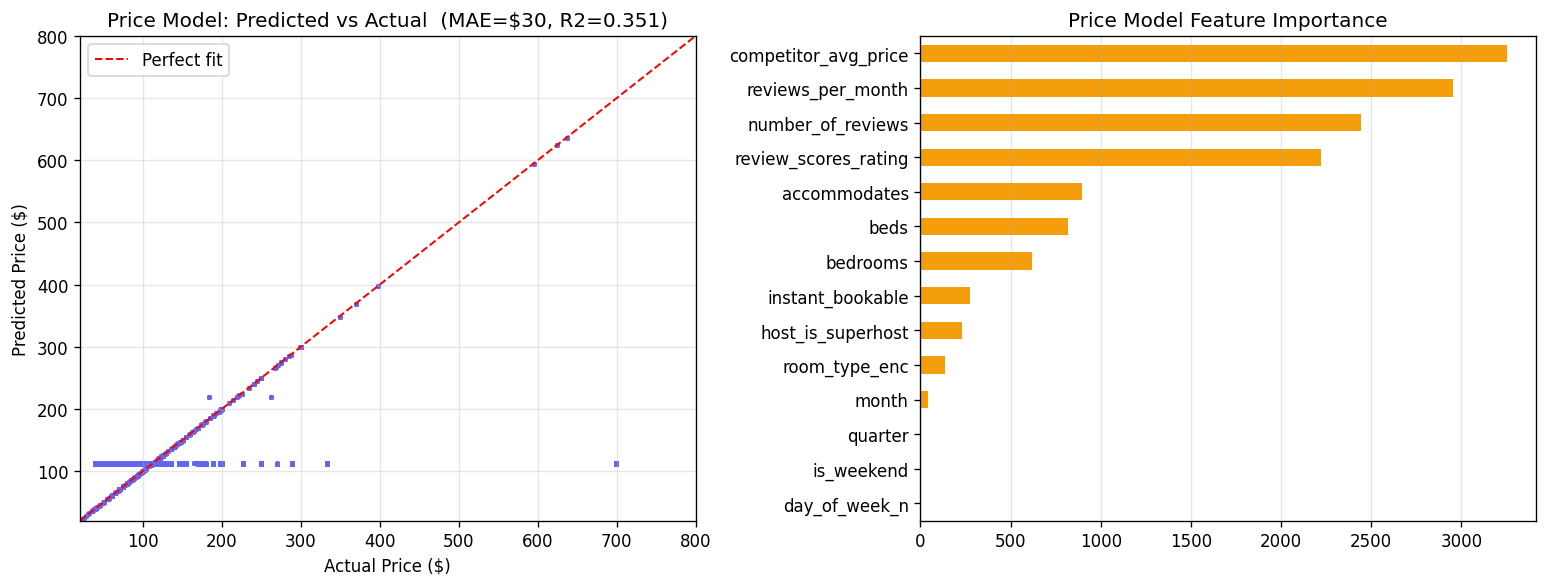

Price model saved ✓


In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score

df_price = df[df['price_num'].between(20, 800)].copy()
df_price = df_price.sort_values('date')
print(f"Rows with valid price: {len(df_price):,}")

# Removed nbhd_est_income (all NaN) and occupancy-caused features
PRICE_FEATURES = [
    'month', 'day_of_week_n', 'is_weekend', 'quarter',
    'accommodates', 'bedrooms', 'beds', 'minimum_nights',
    'review_scores_rating', 'number_of_reviews', 'reviews_per_month',
    'instant_bookable', 'host_is_superhost',
    'room_type_enc',
    'competitor_avg_price',  #
]
PRICE_FEATURES = [f for f in PRICE_FEATURES if f in df_price.columns]
print(f"Price model features ({len(PRICE_FEATURES)}): {PRICE_FEATURES}")

# Time-based split — no dropna here, imputer handles NaN
price_cutoff = df_price['date'].quantile(0.73)
train_p = df_price[df_price['date'] <= price_cutoff]
test_p  = df_price[df_price['date'] >  price_cutoff]

X_train_p = train_p[PRICE_FEATURES]
y_train_p = np.log1p(train_p['price_num'])
X_test_p  = test_p[PRICE_FEATURES]
y_test_p  = np.log1p(test_p['price_num'])

print(f"Train: {len(X_train_p):,}  |  Test: {len(X_test_p):,}")

# LightGBM handles NaN natively — no imputer needed
lgb_price = lgb.LGBMRegressor(
    n_estimators=500, learning_rate=0.05,
    num_leaves=63, min_child_samples=20,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0,
    random_state=SEED, n_jobs=-1, verbose=-1
)
lgb_price.fit(
    X_train_p, y_train_p,
    eval_set=[(X_test_p, y_test_p)],
    callbacks=[lgb.early_stopping(50, verbose=False)]
)

# Evaluate in original dollar space
pred_price   = np.expm1(lgb_price.predict(X_test_p))
actual_price = np.expm1(y_test_p)

mae = mean_absolute_error(actual_price, pred_price)
r2  = r2_score(actual_price, pred_price)
print(f"\nPrice Model  |  MAE: ${mae:.2f}  |  R2: {r2:.4f}")

# Plots
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(actual_price, pred_price, alpha=0.15, s=4, color='#6366f1')
axes[0].plot([20, 800], [20, 800], 'r--', linewidth=1.2, label='Perfect fit')
axes[0].set_xlabel('Actual Price ($)')
axes[0].set_ylabel('Predicted Price ($)')
axes[0].set_title(f'Price Model: Predicted vs Actual  (MAE=${mae:.0f}, R2={r2:.3f})')
axes[0].set_xlim(20, 800); axes[0].set_ylim(20, 800)
axes[0].legend(); axes[0].grid(alpha=0.3)

fi_p = pd.Series(lgb_price.feature_importances_, index=PRICE_FEATURES).sort_values(ascending=True)
fi_p.plot.barh(ax=axes[1], color='#f59e0b')
axes[1].set_title('Price Model Feature Importance')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout(); plt.show()

import joblib
joblib.dump(lgb_price, 'lgb_price_model.pkl')
print('Price model saved ✓')

In [ ]:
# ── Verify: which features matter most for Occupancy vs Price ──

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Occupancy model feature importance
fi_occ = pd.Series(
    lgb_model.feature_importances_, index=FEATURES
).sort_values(ascending=True)

fi_occ.plot.barh(ax=axes[0], color='#6366f1')
axes[0].set_title('Occupancy Model — Feature Importance')
axes[0].grid(axis='x', alpha=0.3)

# Price model feature importance
fi_price = pd.Series(
    lgb_price.feature_importances_, index=PRICE_FEATURES
).sort_values(ascending=True)

fi_price.plot.barh(ax=axes[1], color='#f59e0b')
axes[1].set_title('Price Model — Feature Importance')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# Print top 5 for each model
print("=== Top 5 features for Occupancy ===")
print(fi_occ.tail(5).sort_values(ascending=False).to_string())

print("\n=== Top 5 features for Price ===")
print(fi_price.tail(5).sort_values(ascending=False).to_string())

# Check missing rate for top features in each model
print("\n=== Missing rate of top Occupancy features ===")
top_occ = fi_occ.tail(5).index.tolist()
print(df[top_occ].isnull().mean().round(3))

print("\n=== Missing rate of top Price features ===")
top_price = fi_price.tail(5).index.tolist()
print(df[top_price].isnull().mean().round(3))

In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score

# Filter to sensible price range
df_price = df[df['price_num'].between(20, 800)].copy()
df_price = df_price.sort_values('date')

print(f"Rows with valid price: {len(df_price):,}")

# ── Price features: only static listing attributes ──
# Removed neighbourhood_occ_mean, bookings_last_30d, occ_rate_last_30d
# because occupancy is caused BY price, not the other way around
PRICE_FEATURES = [
    'month', 'day_of_week_n', 'is_weekend', 'quarter',
    'accommodates', 'bedrooms', 'beds', 'minimum_nights',
    'review_scores_rating', 'number_of_reviews', 'reviews_per_month',
    'instant_bookable', 'host_is_superhost',
    'room_type_enc',
    'nbhd_est_income',
]
PRICE_FEATURES = [f for f in PRICE_FEATURES if f in df_price.columns]
print(f"Price model features ({len(PRICE_FEATURES)}): {PRICE_FEATURES}")

# Time-based split
price_cutoff = df_price['date'].quantile(0.73)
train_p = df_price[df_price['date'] <= price_cutoff].dropna(subset=PRICE_FEATURES)
test_p  = df_price[df_price['date'] >  price_cutoff].dropna(subset=PRICE_FEATURES)

X_train_p = train_p[PRICE_FEATURES]
y_train_p = np.log1p(train_p['price_num'])
X_test_p  = test_p[PRICE_FEATURES]
y_test_p  = np.log1p(test_p['price_num'])

print(f"Train: {len(X_train_p):,}  |  Test: {len(X_test_p):,}")

# LightGBM Regressor
lgb_price = lgb.LGBMRegressor(
    n_estimators=500, learning_rate=0.05,
    num_leaves=63, min_child_samples=20,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0,
    random_state=SEED, n_jobs=-1, verbose=-1
)
lgb_price.fit(
    X_train_p, y_train_p,
    eval_set=[(X_test_p, y_test_p)],
    callbacks=[lgb.early_stopping(50, verbose=False)]
)

# Evaluate in original dollar space
pred_price   = np.expm1(lgb_price.predict(X_test_p))
actual_price = np.expm1(y_test_p)

mae = mean_absolute_error(actual_price, pred_price)
r2  = r2_score(actual_price, pred_price)
print(f"\nPrice Model  |  MAE: ${mae:.2f}  |  R2: {r2:.4f}")

# Plots
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(actual_price, pred_price, alpha=0.15, s=4, color='#6366f1')
axes[0].plot([20, 800], [20, 800], 'r--', linewidth=1.2, label='Perfect fit')
axes[0].set_xlabel('Actual Price ($)')
axes[0].set_ylabel('Predicted Price ($)')
axes[0].set_title(f'Price Model: Predicted vs Actual  (MAE=${mae:.0f}, R2={r2:.3f})')
axes[0].set_xlim(20, 800); axes[0].set_ylim(20, 800)
axes[0].legend(); axes[0].grid(alpha=0.3)

fi_p = pd.Series(lgb_price.feature_importances_, index=PRICE_FEATURES).sort_values(ascending=True)
fi_p.plot.barh(ax=axes[1], color='#f59e0b')
axes[1].set_title('Price Model Feature Importance')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout(); plt.show()

import joblib
joblib.dump(lgb_price, 'lgb_price_model.pkl')
print('Price model saved ✓')

In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score

# Filter to sensible price range
df_price = df[df['price_num'].between(20, 800)].copy()
df_price = df_price.sort_values('date')

PRICE_FEATURES = [
    'month', 'day_of_week_n', 'is_weekend', 'quarter',
    'accommodates', 'bedrooms', 'beds', 'minimum_nights',
    'review_scores_rating', 'number_of_reviews', 'reviews_per_month',
    'instant_bookable', 'host_is_superhost',
    'neighbourhood_occ_mean', 'room_type_enc',
    # Demand signals: if a listing was busy last month it can charge more
    'bookings_last_30d', 'occ_rate_last_30d',
    'nbhd_est_income',
]
PRICE_FEATURES = [f for f in PRICE_FEATURES if f in df_price.columns]
print(f"Price model features ({len(PRICE_FEATURES)}): {PRICE_FEATURES}")

# Time-based split (same logic as occupancy model)
price_cutoff = df_price['date'].quantile(0.73)
train_p = df_price[df_price['date'] <= price_cutoff]
test_p  = df_price[df_price['date'] >  price_cutoff]

X_train_p = train_p[PRICE_FEATURES]
y_train_p = np.log1p(train_p['price_num'])
X_test_p  = test_p[PRICE_FEATURES]
y_test_p  = np.log1p(test_p['price_num'])

print(f"Train: {len(X_train_p):,}  |  Test: {len(X_test_p):,}")

# LightGBM Regressor
lgb_price = lgb.LGBMRegressor(
    n_estimators=500, learning_rate=0.05,
    num_leaves=63, min_child_samples=20,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0,
    random_state=SEED, n_jobs=-1, verbose=-1
)
lgb_price.fit(
    X_train_p, y_train_p,
    eval_set=[(X_test_p, y_test_p)],
    callbacks=[lgb.early_stopping(50, verbose=False)]
)

# Evaluate in original dollar space
pred_price   = np.expm1(lgb_price.predict(X_test_p))
actual_price = np.expm1(y_test_p)

mae = mean_absolute_error(actual_price, pred_price)
r2  = r2_score(actual_price, pred_price)
print(f"\nPrice Model  |  MAE: ${mae:.2f}  |  R2: {r2:.4f}")

# Plots
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(actual_price, pred_price, alpha=0.15, s=4, color='#6366f1')
axes[0].plot([20, 800], [20, 800], 'r--', linewidth=1.2, label='Perfect fit')
axes[0].set_xlabel('Actual Price ($)'); axes[0].set_ylabel('Predicted Price ($)')
axes[0].set_title(f'Price Model: Predicted vs Actual  (MAE=${mae:.0f}, R2={r2:.3f})')
axes[0].set_xlim(20, 800); axes[0].set_ylim(20, 800)
axes[0].legend(); axes[0].grid(alpha=0.3)

fi_p = pd.Series(lgb_price.feature_importances_, index=PRICE_FEATURES).sort_values(ascending=True)
fi_p.plot.barh(ax=axes[1], color='#f59e0b')
axes[1].set_title('Price Model Feature Importance')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout(); plt.show()

import joblib
joblib.dump(lgb_price, 'lgb_price_model.pkl')
print('Price model saved to lgb_price_model.pkl')
